# Computational Cognitive Neuroscience and AI

## Week 05 Introduction to Reinforcement Learning

## There are 6 questions and 6 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### This Tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed): https://neuromatch.io/open-education-resources/

This week, we are going to discuss reinforcement learning. Reinforcement Learning (RL) is a framework for defining and solving a problem where an agent learns to take actions in an environment according to the feedback it receives from the environment.

The feedback is typically in the form of reward and the goal of the agent is to maximize reward.

Specifically, the problem setting is as follows: an agent, biological or artificial, observes the current state of the world and selects an action based on that state according to its current policy. Upon executing an action, the agent receives a reward and uses this information to improve its future actions by updating its policy.

The concept of reinforcement learning was first derived from studies of animal behavior in psychology. Later, researchers studying optimal control and operations research provided many theoretical models that generate formal and optimal solutions to reinforcement learning problems. At the same time, neuroscientists also found experimental evidence in the brain that supports some of these reinforcement learning models.

Reinforcement learning can be seen as a framework that allows us to bring in many ideas and formalisms from other areas like psychology, neuroscience, computer science, artificial intelligence, etc. to define algorithms or models that can solve large, complex problems.



In this tutorial, we are going to discuss:

1. Learning to predict: classical conditioning and temporal difference (TD) learning

2. Learning to act in a single state: the multi-armed bandits problem



In [ ]:
# @title Set Up Code

import numpy as np
import matplotlib.pyplot as plt

# Figure Settings

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")


# Plotting Functions

from matplotlib import ticker

def plot_value_function(V, ax=None, show=True):
  """Plot V(s), the value function"""
  if not ax:
    fig, ax = plt.subplots()

  ax.stem(V)
  ax.set_ylabel('Value')
  ax.set_xlabel('State')
  ax.set_title("Value function: $V(s)$")

  if show:
    plt.show()


def plot_tde_trace(TDE, ax=None, show=True, skip=400):
  """Plot the TD Error across trials"""
  if not ax:
    fig, ax = plt.subplots()

  indx = np.arange(0, TDE.shape[1], skip)
  im = ax.imshow(TDE[:,indx])
  positions = ax.get_xticks()
  # Avoid warning when setting string tick labels
  ax.xaxis.set_major_locator(ticker.FixedLocator(positions))
  ax.set_xticklabels([f"{int(skip * x)}" for x in positions])
  ax.set_title('TD-error over learning')
  ax.set_ylabel('State')
  ax.set_xlabel('Iterations')
  ax.figure.colorbar(im)
  if show:
    plt.show()


def learning_summary_plot(V, TDE):
  """Summary plot for Ex1"""
  fig, (ax1, ax2) = plt.subplots(nrows = 2, gridspec_kw={'height_ratios': [1, 2]})

  plot_value_function(V, ax=ax1, show=False)
  plot_tde_trace(TDE, ax=ax2, show=False)
  plt.tight_layout()
  plt.show()

# Helper Functions and Classes

def reward_guesser_title_hint(r1, r2):
  """"Provide a mildly obfuscated hint for a demo."""
  if (r1==14 and r2==6) or (r1==6 and r2==14):
    return "Technically correct...(the best kind of correct)"

  if  ~(~(r1+r2) ^ 11) - 1 == (6 | 24): # Don't spoil the fun :-)
    return "Congratulations! You solved it!"

  return "Keep trying...."


class ClassicalConditioning:

    def __init__(self, n_steps, reward_magnitude, reward_time):

        # Task variables
        self.n_steps = n_steps
        self.n_actions = 0
        self.cs_time = int(n_steps/4) - 1  # Time step at which the conditional stimulus is presented

        # Reward variables
        self.reward_state = [0,0]
        self.reward_magnitude = None
        self.reward_probability = None
        self.reward_time = None

        # reward_time is the number of time steps after CS at which the reward is presented
        self.set_reward(reward_magnitude, reward_time)

        # Create a state dictionary
        self._create_state_dictionary()

    def set_reward(self, reward_magnitude, reward_time):

        """
        Determine reward state and magnitude of reward
        """
        if reward_time >= self.n_steps - self.cs_time: # reward_time is the number of time steps after CS at which the reward is presented
            self.reward_magnitude = 0

        else:
            self.reward_magnitude = reward_magnitude
            self.reward_state = [1, reward_time]

    def get_outcome(self, current_state):

        """
        Determine next state and reward
        """
        # Update state
        if current_state < self.n_steps - 1:
            next_state = current_state + 1
        else:
            next_state = 0

        # Check for reward
        if self.reward_state == self.state_dict[current_state]:
            reward = self.reward_magnitude
        else:
            reward = 0

        return next_state, reward

    def _create_state_dictionary(self):

        """
        This dictionary maps number of time steps/ state identities
        in each episode to some useful state attributes:

        state      - 0 1 2 3 4 5 (cs) 6 7 8 9 10 11 12 ...
        is_delay   - 0 0 0 0 0 0 (cs) 1 1 1 1  1  1  1 ...
        t_in_delay - 0 0 0 0 0 0 (cs) 1 2 3 4  5  6  7 ...
        """
        d = 0

        self.state_dict = {}
        for s in range(self.n_steps):
            if s <= self.cs_time:
                self.state_dict[s] = [0,0]
            else:
                d += 1 # Time in delay
                self.state_dict[s] = [1,d]


class MultiRewardCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that one randomly selected reward,
    magnitude, from a list, is delivered of a single fixed reward."""
  def __init__(self, n_steps, reward_magnitudes, reward_time=None):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: LIST of possible reward magnitudes.
        - reward_time: Single fixed reward time
      Uses numpy global random state.
      """
    super().__init__(n_steps, 1, reward_time)
    self.reward_magnitudes = reward_magnitudes

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward=np.random.choice(self.reward_magnitudes)
    return next_state, reward


class ProbabilisticCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that rewards are stochastically omitted."""
  def __init__(self, n_steps, reward_magnitude, reward_time=None, p_reward=0.75):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: Reward magnitudes.
        - reward_time: Single fixed reward time.
        - p_reward: probability that reward is actually delivered in rewarding state
      Uses numpy global random state.
      """
    super().__init__(n_steps, reward_magnitude, reward_time)
    self.p_reward = p_reward

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward*= int(np.random.uniform(size=1)[0] < self.p_reward)
    return next_state, reward












!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W3D4_T2"




np.set_printoptions(precision=3)

def plot_choices(q, epsilon, choice_fn, n_steps=1000, rng_seed=1):
  np.random.seed(rng_seed)
  counts = np.zeros_like(q)
  for t in range(n_steps):
    action = choice_fn(q, epsilon)
    counts[action] += 1

  fig, ax = plt.subplots()
  ax.bar(range(len(q)), counts/n_steps)
  ax.set(ylabel='% chosen', xlabel='action', ylim=(0,1), xticks=range(len(q)))
  plt.show()


def plot_multi_armed_bandit_results(results):
  fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15, 5))
  ax1.plot(results['rewards'])
  ax1.set(title=f"Total Reward: {np.sum(results['rewards']):.2f}",
          xlabel='step', ylabel='reward')
  ax2.plot(results['qs'])
  ax2.set(xlabel='step', ylabel='value')
  ax2.legend(range(len(results['mu'])))
  ax3.plot(results['mu'], label='latent')
  ax3.plot(results['qs'][-1], label='learned')
  ax3.set(xlabel='action', ylabel='value')
  ax3.legend()
  plt.show()


def plot_parameter_performance(labels, fixed, trial_rewards, trial_optimal):
  fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))

  ax1.plot(np.mean(trial_rewards, axis=1).T)
  ax1.set(title=f'Average Reward ({fixed})', xlabel='step', ylabel='reward')
  ax1.legend(labels)

  ax2.plot(np.mean(trial_optimal, axis=1).T)
  ax2.set(title=f'Performance ({fixed})', xlabel='step', ylabel='% optimal')
  ax2.legend(labels)
  plt.show()





def plot_choices_ucb(q, c, n_i, choice_fn, n_steps=1000, rng_seed=1):
  np.random.seed(rng_seed)
  counts = np.zeros_like(q)
  for t in range(n_steps):
    action = choice_fn(q, c, n_i)
    counts[action] += 1

  fig, ax = plt.subplots()
  ax.bar(range(len(q)), counts/n_steps)
  ax.set(ylabel='% chosen', xlabel='action', ylim=(0,1), xticks=range(len(q)))
  plt.show()









from scipy.signal import convolve as conv

def plot_state_action_values(env, value, ax=None, show=False):
  """
  Generate plot showing value of each action at each state.
  """
  if ax is None:
    fig, ax = plt.subplots()

  for a in range(env.n_actions):
    ax.plot(range(env.n_states), value[:, a], marker='o', linestyle='--')
  ax.set(xlabel='States', ylabel='Values')
  ax.legend(['R','U','L','D'], loc='lower right')
  if show:
    plt.show()


def plot_quiver_max_action(env, value, ax=None, show=False):
  """
  Generate plot showing action of maximum value or maximum probability at
    each state (not for n-armed bandit or cheese_world).
  """
  if ax is None:
    fig, ax = plt.subplots()

  X = np.tile(np.arange(env.dim_x), [env.dim_y,1]) + 0.5
  Y = np.tile(np.arange(env.dim_y)[::-1][:,np.newaxis], [1,env.dim_x]) + 0.5
  which_max = np.reshape(value.argmax(axis=1), (env.dim_y,env.dim_x))
  which_max = which_max[::-1,:]
  U = np.zeros(X.shape)
  V = np.zeros(X.shape)
  U[which_max == 0] = 1
  V[which_max == 1] = 1
  U[which_max == 2] = -1
  V[which_max == 3] = -1

  ax.quiver(X, Y, U, V)
  ax.set(
      title='Maximum value/probability actions',
      xlim=[-0.5, env.dim_x+0.5],
      ylim=[-0.5, env.dim_y+0.5],
  )
  ax.set_xticks(np.linspace(0.5, env.dim_x-0.5, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_xticks(np.arange(env.dim_x+1), minor=True)
  ax.set_yticks(np.linspace(0.5, env.dim_y-0.5, num=env.dim_y))
  ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x,
                                                  env.dim_x)])
  ax.set_yticks(np.arange(env.dim_y+1), minor=True)
  ax.grid(which='minor',linestyle='-')
  if show:
    plt.show()


def plot_heatmap_max_val(env, value, ax=None, show=False):
  """
  Generate heatmap showing maximum value at each state
  """
  if ax is None:
    fig, ax = plt.subplots()

  if value.ndim == 1:
      value_max = np.reshape(value, (env.dim_y,env.dim_x))
  else:
      value_max = np.reshape(value.max(axis=1), (env.dim_y,env.dim_x))
  value_max = value_max[::-1, :]

  im = ax.imshow(value_max, aspect='auto', interpolation='none', cmap='afmhot')
  ax.set(title='Maximum value per state')
  ax.set_xticks(np.linspace(0, env.dim_x-1, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_yticks(np.linspace(0, env.dim_y-1, num=env.dim_y))
  if env.name != 'windy_cliff_grid':
    ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x, env.dim_x)][::-1])
  if show:
    plt.show()
  return im


def plot_rewards(n_episodes, rewards, average_range=10, ax=None, show=False):
  """
  Generate plot showing total reward accumulated in each episode.
  """
  if ax is None:
    fig, ax = plt.subplots()

  smoothed_rewards = (conv(rewards, np.ones(average_range), mode='same')
                      / average_range)

  ax.plot(range(0, n_episodes, average_range),
          smoothed_rewards[0:n_episodes:average_range],
          marker='o', linestyle='--')
  ax.set(xlabel='Episodes', ylabel='Total reward')
  if show:
    plt.show()


def plot_performance(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
  plot_state_action_values(env, value, ax=axes[0, 0])
  plot_quiver_max_action(env, value, ax=axes[0, 1])
  plot_rewards(n_episodes, reward_sums, ax=axes[1, 0])
  im = plot_heatmap_max_val(env, value, ax=axes[1, 1])
  fig.colorbar(im)
  plt.show(fig)











  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.5 MB/s eta 0:00:00


# Learning to predict: classical conditioning and temporal difference (TD) learning

In this section, we will model the agent as an observer that learns to predict future rewards. This agent takes no actions and thus cannot influence how much reward it receives. By predicting how much reward follows from each state, the agent can learn to identify the best states of the world -- i.e. the ones that tend to be followed by the most reward.

More specifically, we will learn how to estimate state-value functions in a classical conditioning paradigm using Temporal Difference (TD) learning and examine TD-errors at the presentation of the conditioned and unconditioned stimulus (CS and US) under different CS-US contingencies. This section will provide you with an understanding of both how reward prediction errors (RPEs) behave in classical conditioning and how it is related to dopamine neurons' behavior.

## According to experimental findings, dopamine neurons report reward prediction errors.


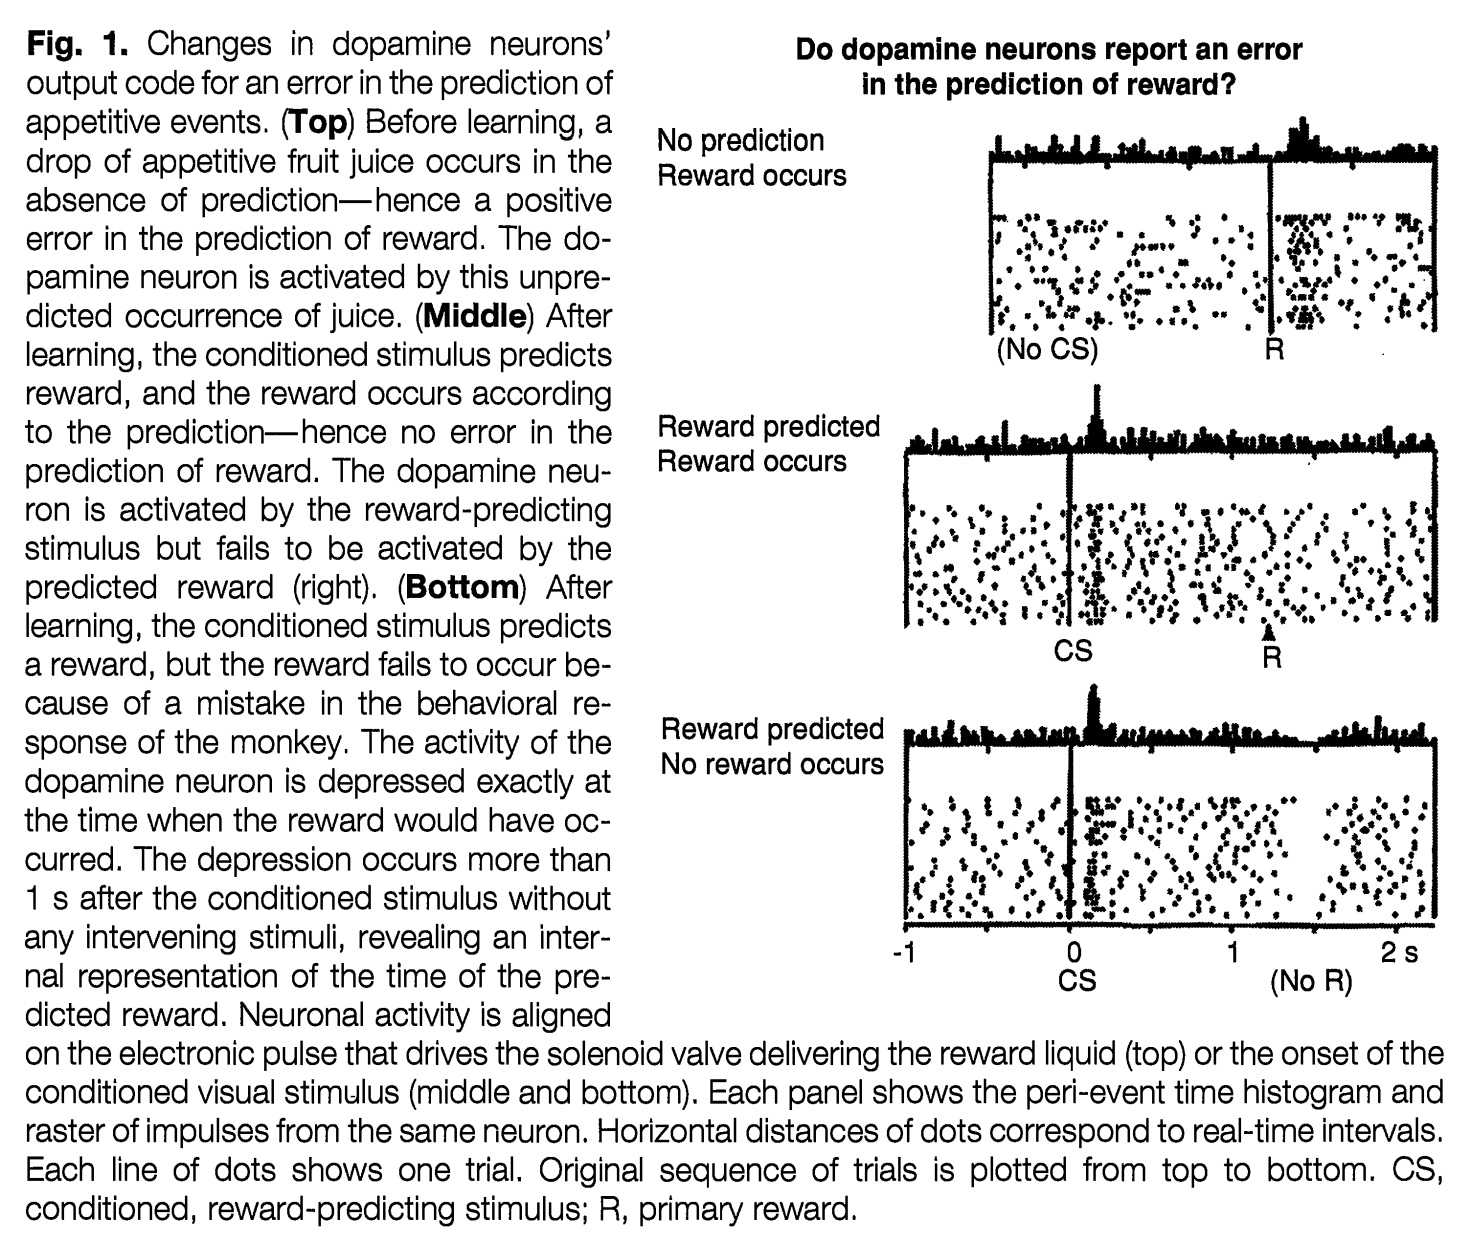

reference: https://www.science.org/doi/10.1126/science.275.5306.1593

# Question 1

What conclusion can you make based on the experimental results shown above?

## Concepts and definitions for modeling

Let us try to use modeling to explain dopamine neurons' behavior.

**Concepts:**

- **Classical conditioning**:

 - Classical conditioning is a learning process where an organism learns to associate two stimuli, such that a neutral stimulus (one that initially has no effect) comes to elicit a response after being paired with a stimulus that naturally elicits that response.

 - Example: Pavlov's famous experiment where dogs learned to associate a bell (neutral stimulus) with food (natural stimulus), eventually salivating (response) at the sound of the bell alone.

- **Unconditioned stimulus** (US):

 - An unconditioned stimulus is a stimulus that naturally and automatically triggers a response without prior learning. The response to the US is innate or reflexive, not learned.

 - Example: Food (reward) in Pavlov's experiment acts as the US because it naturally causes dogs to salivate.

- **Conditioned stimulus** (CS):  

 - A conditioned stimulus is initially a neutral stimulus that, after being repeatedly paired with an unconditioned stimulus, begins to elicit a response on its own. The response to the CS is learned through association with the US.

 - Example: The sound of a bell (cue) in Pavlov's experiment acts as the CS after being paired with food (US). Initially neutral, the bell eventually elicits salivation (response) after conditioning.





**A Classical conditioning Environment:**

- The agent experiences the environment in episodes (also known as trials).
- Episodes terminate by transitioning to the inter-trial-interval (ITI) state and they are initiated from the ITI state as well. We clamp the value of the terminal/ITI states to zero.
- The classical conditioning environment is composed of a sequence of states that the agent deterministically transitions through. Starting at State 0, the agent moves to State 1 in the first step, from State 1 to State 2 in the second, and so on.  These states represent time in what is called "tapped delay line" representation
- Within each episode, the agent is presented with a CS (cue) and US (reward).
- The CS (cue) is presented at the end of the first quarter the trial. The US (reward) is delivered shortly afterwards. The interval between the CS and US is specified by `reward_time`.
- The agent's goal is to learn to predict expected rewards from each state in the trial.

**Definitions**

* **State $s$**: The current state, typically obtained from observations that the agent receives from the environment.

* **[Markovian assumption](https://en.wikipedia.org/wiki/Markov_property)**: It assumes that state transitions have the memoryless property, which means that a future state transition is only dependent on the current state and it is independent of the history (states in the past).

* **Return $G_{t}$**: future cumulative reward at time $t$:
\begin{equation}
G_{t} = \sum \limits_{k = 0}^{\infty} \gamma^{k} r_{t+k+1}
\end{equation}
where $r_{t}$ is the amount of reward received at time $t$, and $\gamma \in [0, 1]$ is a discount factor that specifies the relevance in the present of future rewards.

 Note that the return $G_{t}$ can be written in a recursive form:
\begin{equation}
G_{t} = r_{t+1} + \gamma G_{t+1}
\end{equation}

* **The state-value function $V(s_t=s)$**: It is defined as the expected return (future cumulative reward) starting with state $s$.

\begin{align}
V(s_t=s) &= \mathbb{E} [ G_{t}\; | \; s_t=s] \\
& = \mathbb{E} [ r_{t+1} + \gamma G_{t+1}\; | \; s_t=s]\\
&= \mathbb{E} [ r_{t+1} + \gamma V(s_{t+1})\; | \; s_t=s]
\end{align}


**Temporal difference (TD) learning**

* **Temporal difference error (TD-error)**:
\begin{align}
\delta_{t} = r_{t+1} + \gamma V(s_{t+1}) - V(s_{t})
\end{align}

 The TD-error measures the discrepancy between the current estimate $V(s_{t})$ and the target $r_{t+1} + \gamma V(s_{t+1})$.

 In other words, TD-error is measuring the **reward prediction error (RPE)**.

* **Value update**: Once the TD-error is calculated, we can perform a "value update" to reduce the discrepancy between the value estimation and the target:

\begin{align}
V(s_{t}) \leftarrow V(s_{t}) + \alpha \delta_{t}
\end{align}

  where $\alpha$ is a learning rate that specifies the speed of learning.

Reference: McClelland, J. L., Rumelhart, D. E. (1989). Explorations in parallel distributed processing: A handbook of models, programs, and exercises. Chapter 9, MIT press. url: [web.stanford.edu/group/pdplab/pdphandbook/handbookch10.html](https://web.stanford.edu/group/pdplab/pdphandbook/handbookch10.html)

# Question 2

According to the TD learning model described above, what might the signals of dopamine neurons represent? i.e. which part of the equation might be represented by dopamine neurons' firing rates?

## TD-learning with guaranteed rewards

### Implement TD-learning

Now, we will implement TD-learning to estimate the state-value function $V(s)$ in the classical conditioning paradigm. Rewards (unconditional stimulus, US) have fixed magnitude and are delivered at a fixed time delay after the conditioned stimulus (CS). We should save the TD-errors over learning (i.e., over trials) so we can visualize them afterwards.

In order to simulate the effect of the CS, we should update $V(s_{t})$ only during the delay period after CS. This period is indicated by the boolean variable `is_delay`. This can be implemented by multiplying the expression for updating the value function by `is_delay`.

Use the provided code to estimate the value function. We will use helper class `ClassicalConditioning` in the set up code.

We can use help() to check the helper class `ClassicalConditioning` and understand how to use it:

In [ ]:
help(ClassicalConditioning)

Help on class ClassicalConditioning in module __main__:

class ClassicalConditioning(builtins.object)
 |  ClassicalConditioning(n_steps, reward_magnitude, reward_time)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, n_steps, reward_magnitude, reward_time)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  get_outcome(self, current_state)
 |      Determine next state and reward
 |  
 |  set_reward(self, reward_magnitude, reward_time)
 |      Determine reward state and magnitude of reward
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables
 |  
 |  __weakref__
 |      list of weak references to the object



# Coding Exercise #1

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at lines 34 and 37 and comment or remove the next line
raise NotImplementedError("Coding Exercise #1")
#############################################################################

def td_learner(env, n_trials, gamma=0.98, alpha=0.001):
  """ Temporal Difference learning

  Args:
    env (object): the environment to be learned
    n_trials (int): the number of trials to run
    gamma (float): temporal discount factor
    alpha (float): learning rate

  Returns:
    ndarray, ndarray: the value function and temporal difference error arrays
  """
  V = np.zeros(env.n_steps) # Array to store values over states (time)
  TDE = np.zeros((env.n_steps, n_trials)) # Array to store TD errors

  for n in range(n_trials):

    state = 0 # Initial state
    for t in range(env.n_steps):

      # Get next state and next reward
      next_state, reward = env.get_outcome(state)

      # Is the current state in the delay period (after CS)?
      is_delay = env.state_dict[state][0]

      # Write an expression to compute the TD-error
      TDE[state, n] = ...

      # Write an expression to update the value function
      V[state] = ... # Only update the value function after the CS

      # Update state
      state = next_state

  return V, TDE




Suppose in a classical conditioning environment, the the conditional stimulus (CS) is presented at the time step `int(n_steps/4) - 1` and the reward (US) is presented at 10 time steps after CS. There are 20000 trials (number of iterations) in total.

We can use the function `td_learner` that we wrote above to compute TD-errors and value updates. We can visualize the results and check how the value function and the TD-error change over different trials.

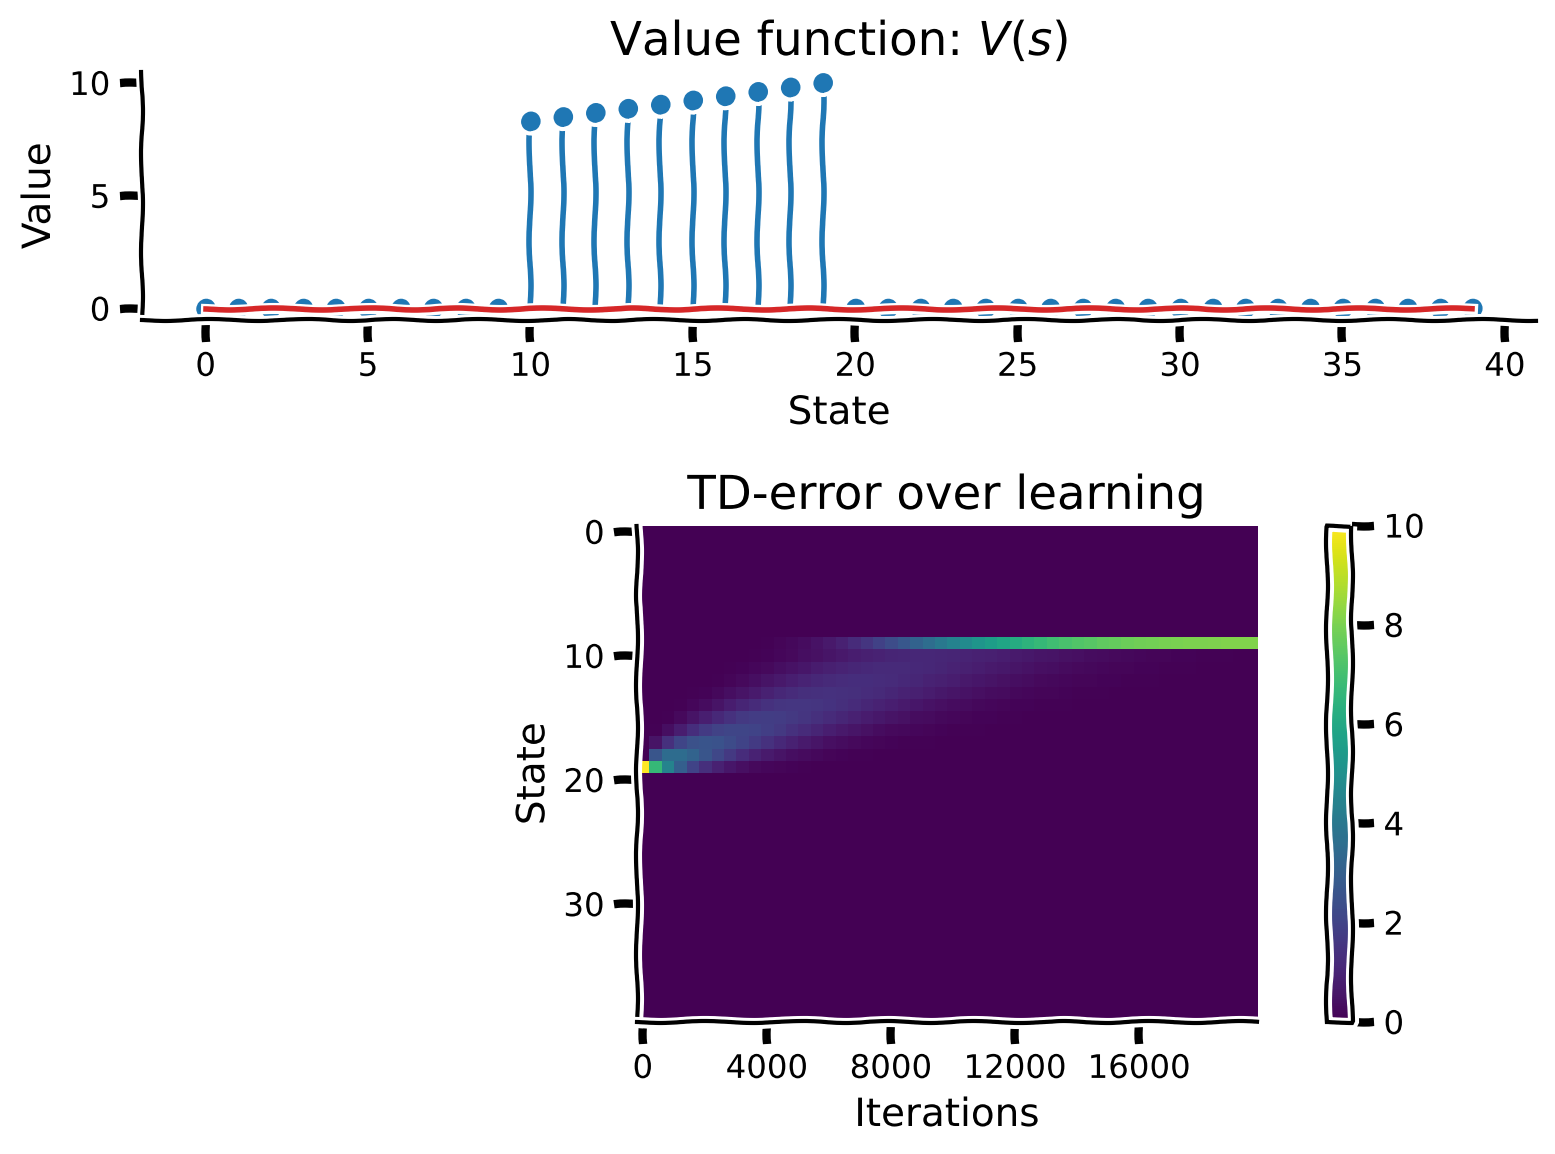

In [ ]:

# Initialize classical conditioning class
env = ClassicalConditioning(n_steps=40, reward_magnitude=10, reward_time=10) # reward_time is the time of US

# Perform temporal difference learning
V, TDE = td_learner(env, n_trials=20000)

# Visualize
with plt.xkcd():
  learning_summary_plot(V, TDE)

### Interactive Demo : US to CS Transfer

According to the simulation results that we got above, in classical conditioning, the subject's behavioral response (e.g., salivating) transfers from the unconditioned stimulus (US; like the smell of tasty food) to the conditioned stimulus (CS; like Pavlov ringing his bell) that predicts it after a large number of trials.

It is because when there are more and more trials, the reward prediction errors adjust the values of states according to their expected, discounted return.

Recall that TD-errors are given by:

\begin{equation}
\delta_{t} = r_{t+1} + \gamma V(s_{t+1}) - V(s_{t})
\end{equation}

And the value function is updated by:

\begin{align}
V(s_{t}) \leftarrow V(s_{t}) + \alpha \delta_{t}
\end{align}

The delay period has zero reward, so throughout the learning phase, the TD-errors result from inconsistencies between $\gamma V(s_{t+1})$ and $V(s_{t})$. When the value at a given time point is being updated over many trials, $V(s_{t})$ increases and approaches $\gamma V(s_{t+1})$. As a result, the TD-error for a given time point will diminish to 0. However, it will also cause the TD-error for the preceding time point to increase because $\gamma V(s_{t}) - V(s_{t-1})$ will increase. Thus, throughout learning, the TD-errors will tend to move backwards in time.

\

Let us use the widget below to examine how TD-errors (reward prediction errors) change over time.

The blue lines show the TD-errors in the current trial. The orange line shows the TD-errors before training (in trial #1). The green line shows the TD-errors after infinity number of trials.


In [ ]:

n_trials = 20000

@widgets.interact
def plot_tde_by_trial(trial = widgets.IntSlider(value=5000, min=0, max=n_trials-1 , step=1, description="Trial #")):
  if 'TDE' not in globals():
    print("Complete Coding Exercise to enable this interactive demo")
  else:

    fig, ax = plt.subplots()
    ax.axhline(0, color='k') # Use this + basefmt=' ' to keep the legend clean.
    ax.stem(TDE[:, 0], linefmt='C1-', markerfmt='C1d', basefmt=' ',
            label="Before Learning (Trial 0)")
    ax.stem(TDE[:, -1], linefmt='C2-', markerfmt='C2s', basefmt=' ',
            label=r"After Learning (Trial $\infty$)")
    ax.stem(TDE[:, trial], linefmt='C0-', markerfmt='C0o', basefmt=' ',
            label=f"Trial {trial}")

    ax.set_xlabel("State in trial")
    ax.set_ylabel("TD Error")
    ax.set_title("Temporal Difference Error by Trial")
    ax.legend()
    plt.show()


interactive(children=(IntSlider(value=5000, description='Trial #', max=19999), Output()), _dom_classes=('widge…

Dopamine neurons have been found to show exactly the same the TD-error US to CS transfer behavior that we have found above in our artificial simulations. Therefore, dopamine neurons are thought to carry reward prediction errors _in vivo_.


### Interactive Demo: Learning Rates and Discount Factors

Our TD-learning agent has two parameters that control how it learns: $\alpha$, the learning rate, and $\gamma$, the discount factor. In the previous simulations, we set these parameters to $\alpha=0.001$ and $\gamma=0.98$. Here, we'll investigate how changing these parameters affect the value function that the TD-learning agent learns.

Before enabling the interactive demo below, take a moment to think about the functions of these two parameters.

$\alpha$ controls the size of the Value function updates produced by each TD-error. In our current simple, deterministic environment, will this affect the final value function that the agent learns? Is a larger $\alpha$ necessarily better in more complex, dynamic environments?

The discount rate $\gamma$ applies an exponentially-decaying weight to returns occuring in the future, rather than the present timestep. How does this affect the value function that the agent learns? What happens when $\gamma=0$ or $\gamma \geq 1$?

Use the widget to test your hypotheses.

In [ ]:

@widgets.interact
def plot_summary_alpha_gamma(alpha=widgets.FloatSlider(value=0.0001, min=0.0001,
                                                       max=0.001, step=0.0001,
                                                       readout_format='.4f',
                                                       description="alpha"),
                             gamma=widgets.FloatSlider(value=0.980, min=0,
                                                       max=1.1, step=0.010,\
                                                       description="γ")):
  env = ClassicalConditioning(n_steps=40, reward_magnitude=10, reward_time=10)
  try:
    V_params, TDE_params = td_learner(env, n_trials=20000, gamma=gamma,
                                      alpha=alpha)
  except NotImplementedError:
    print("Finish Coding Exercise to enable this interactive demo")

  learning_summary_plot(V_params,TDE_params)




interactive(children=(FloatSlider(value=0.0001, description='alpha', max=0.001, min=0.0001, readout_format='.4…

# Questions 3

1. What can you find based on the interactive demo shown above? How does changing alpha and gamma affect the value function and TD-error?

2. Why changing alpha and gamma affect the value function and TD-error in this way?

3. Can you predict what would happen to real dopamine neurons' responses at the time of the conditional stimulus at different trials (e.g. early trials and later trials) when the animal is very greedy about the reward (i.e. discount factor $\gamma$ is very small)?  

4. Can you predict what would happen to real dopamine neurons' responses at the time of the unconditional stimulus (reward) at different trials (e.g. early trials and later trials) when the animal's learning is very greedy (i.e. learning rate $\alpha$ is very large)?  

## TD-learning with varying reward magnitudes

In the previous section, the environment was as simple as possible. On every trial, the CS predicted the same reward, at the same time, with 100% certainty. In this section, we will make the environment more complicated and examine the TD-learner's behavior.

### Interactive Demo: Match the Value Functions

First, let us change the environment. Now there are two kinds of rewards: reward magnitude = 6 units or 14 units. Both rewards are equally likely. In addition, each reward will be dispensed at random with a $50\%$ probability.

The interative demo that is shown below shows the final value function $V(s)$ for a TD learner that was trained in this environment.


# Question 4

1. Can you find another pair of rewards that cause the agent to learn the same value function? Assume each reward will be dispensed $50\%$ of the time.

2. What is the general requirement that the this pair of rewards should satisfy to cause the agent to learn the same value function?

Hints:

* Carefully consider the definition of the value function $V$. This can be solved analytically.
* It is unrelated to $\alpha$ or $\gamma$.

In [ ]:

# Please allow some time for the new figure to load

n_trials = 20000
np.random.seed(2020)
rng_state = np.random.get_state()
env = MultiRewardCC(40, [6, 14], reward_time=10)
V_multi, TDE_multi = td_learner(env, n_trials, gamma=0.98, alpha=0.001)

@widgets.interact
def reward_guesser_interaction(r1 = widgets.IntText(value=0, min=0, max=50, description="Reward 1"),
                               r2 = widgets.IntText(value=0, min=0, max=50, description="Reward 2")):
  try:
    env2 = MultiRewardCC(40, [r1, r2], reward_time=10)
    V_guess, _ = td_learner(env2, n_trials, gamma=0.98, alpha=0.001)
    fig, ax = plt.subplots()
    m, l, _ = ax.stem(V_multi, linefmt='y-', markerfmt='yo',
                      basefmt=' ', label="Target")
    m.set_markersize(15)
    m.set_markerfacecolor('none')
    l.set_linewidth(4)
    m, _, _ = ax.stem(V_guess, linefmt='r', markerfmt='rx',
                      basefmt=' ', label="Guess")
    m.set_markersize(15)

    ax.set_xlabel("State")
    ax.set_ylabel("Value")
    ax.set_title(f"Guess V(s)\n{reward_guesser_title_hint(r1, r2)}")
    ax.legend()
    plt.show()
  except NotImplementedError:
    print("Please finish Coding Exercise first")

interactive(children=(IntText(value=0, description='Reward 1'), IntText(value=0, description='Reward 2'), Outp…

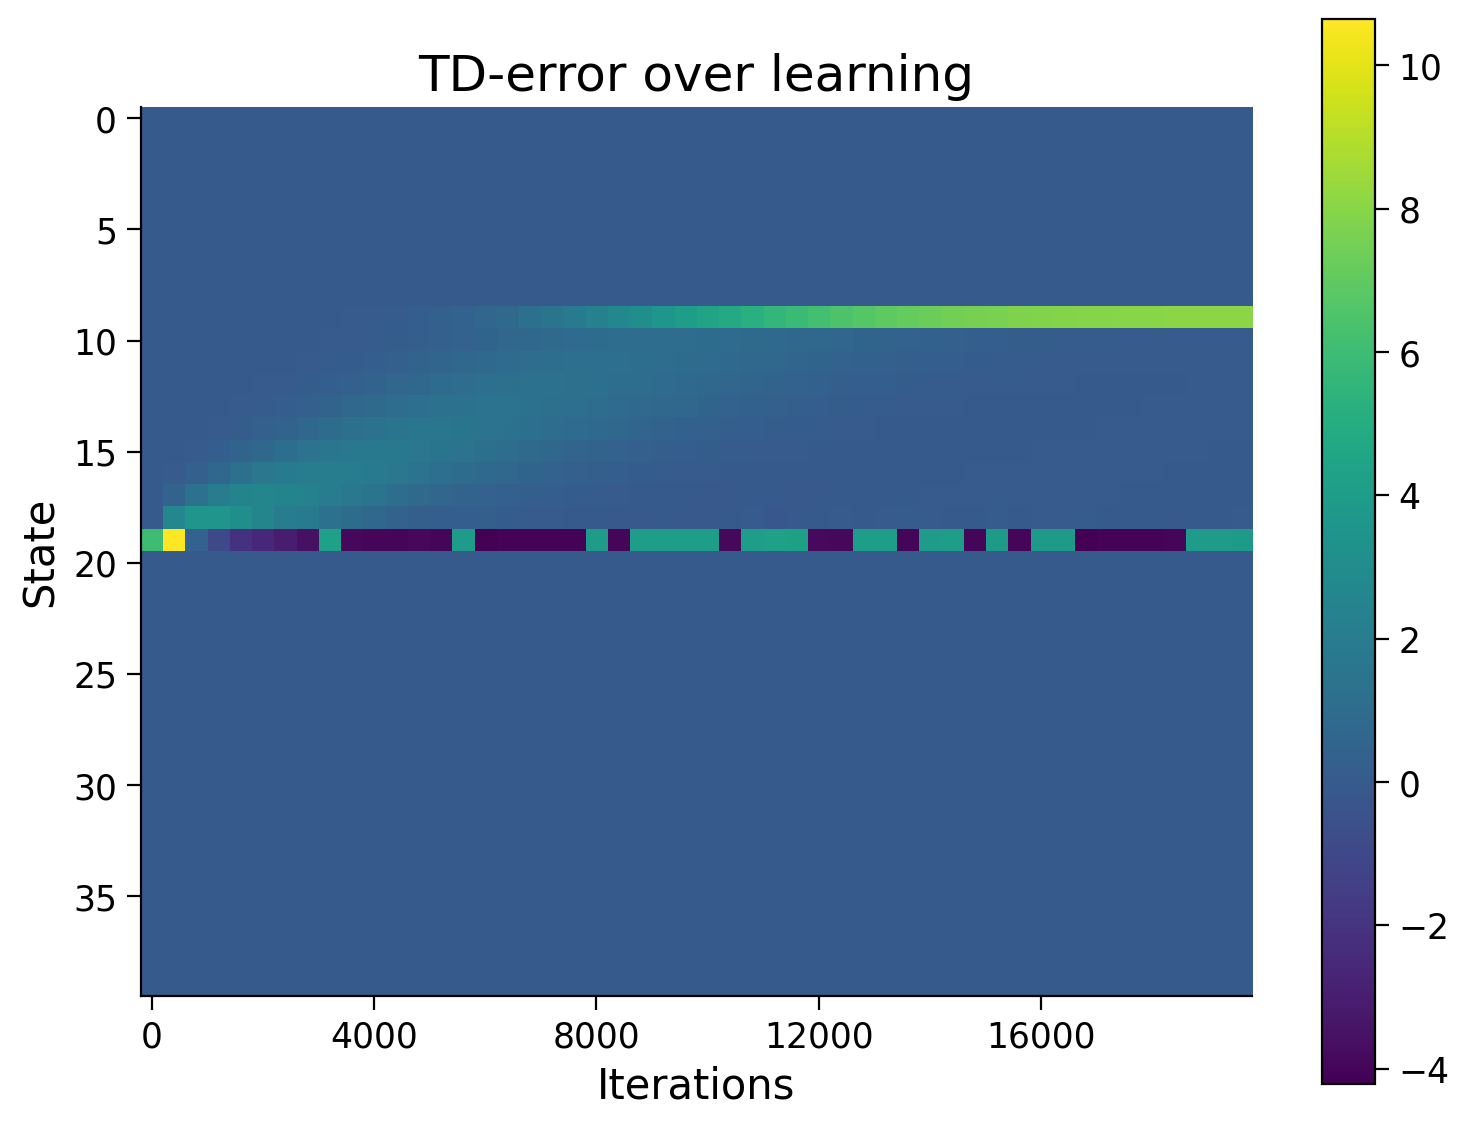

In [ ]:

plot_tde_trace(TDE_multi)

## TD-learning with probabilistic rewards

### Interactive Demo: TD-learning with probabilistic rewards

In this environment, we'll return to delivering a single reward of ten units. However, it will be delivered intermittently: on 20 percent of trials, the CS will be shown but the agent will not receive the usual reward; the remaining 80% will proceed as usual.

Run the cell below to simulate. Recall that earlier in the notebook, we saw that changing $\alpha$ had little effect on learning in a deterministic environment. In the first simulation below, $\alpha$ is set to 1. What happens when the learning rate is set to such a large value in a probability reward setting? Does it seem like it will _ever_ converge?


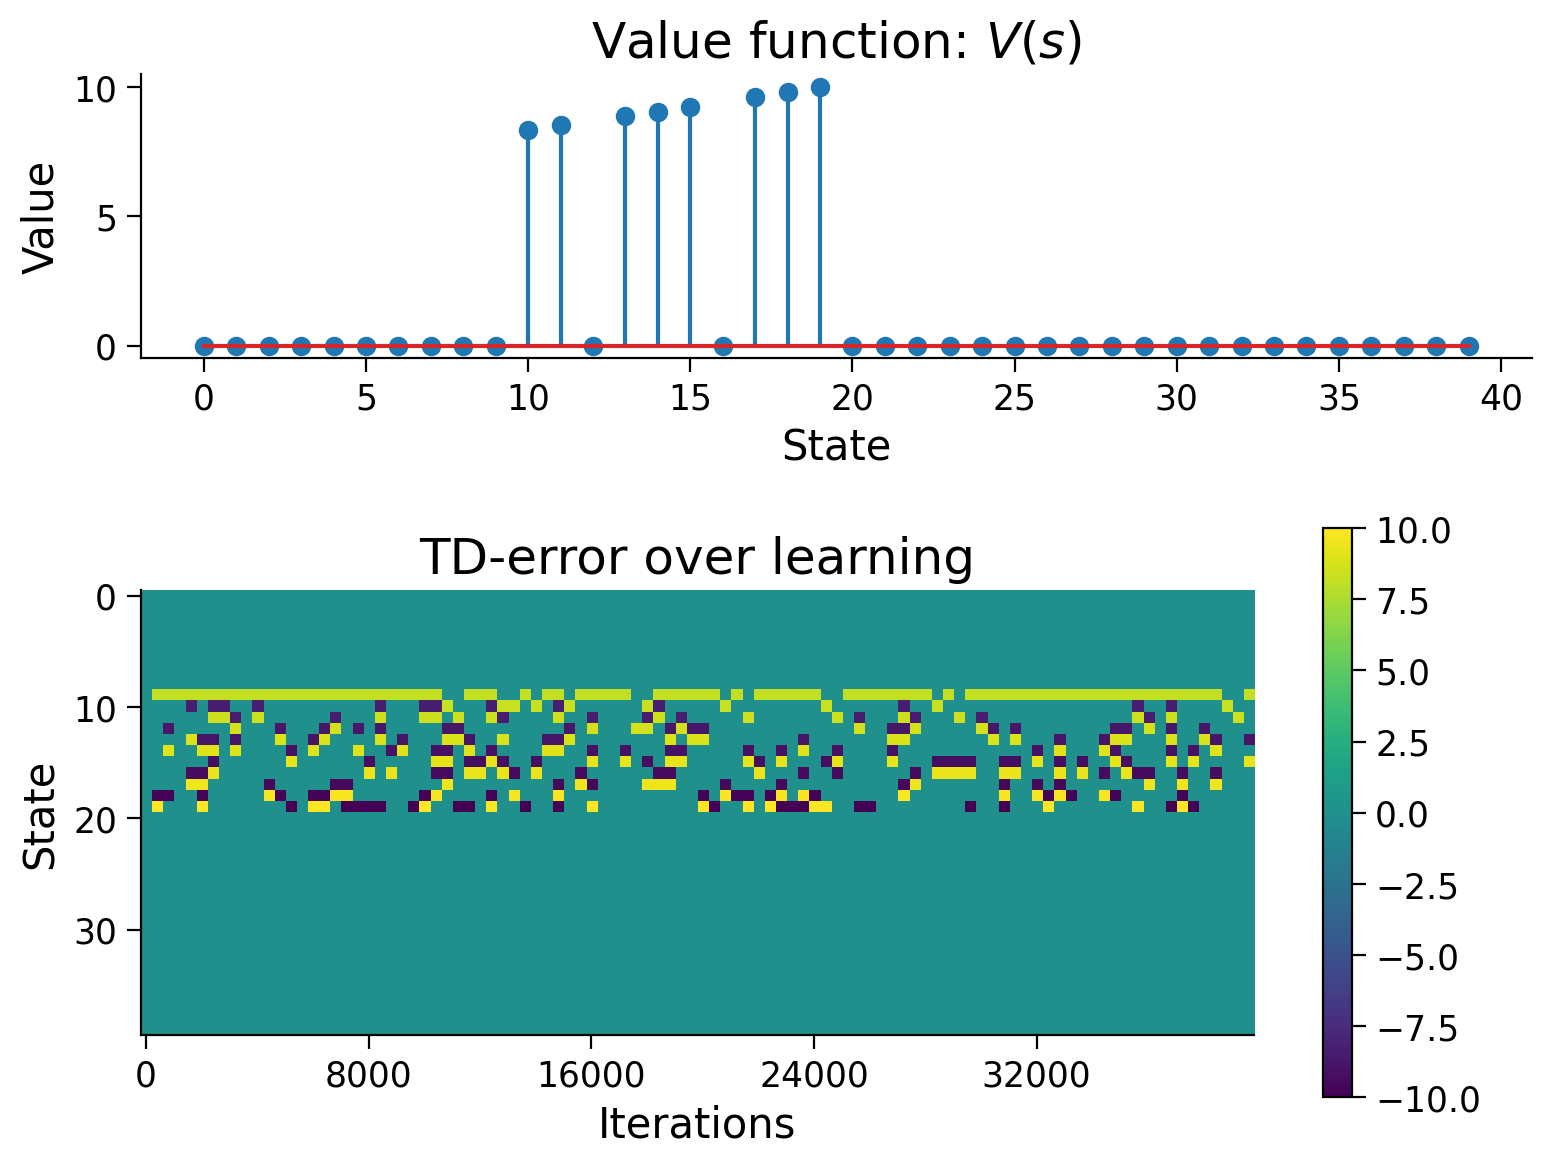

In [ ]:

# Execute this cell to visualize the value function and TD-errors when `alpha=1`
np.random.set_state(rng_state)  # Resynchronize everyone's notebooks
n_trials = 20000
try:
  env = ProbabilisticCC(n_steps=40, reward_magnitude=10, reward_time=10,
                        p_reward=0.8)
  V_stochastic, TDE_stochastic = td_learner(env, n_trials*2, alpha=1)
  learning_summary_plot(V_stochastic, TDE_stochastic)
except NotImplementedError:
  print("Please finish Coding Exercise first")

We can then reduce the learning rate to 0.002 to see what will happen:

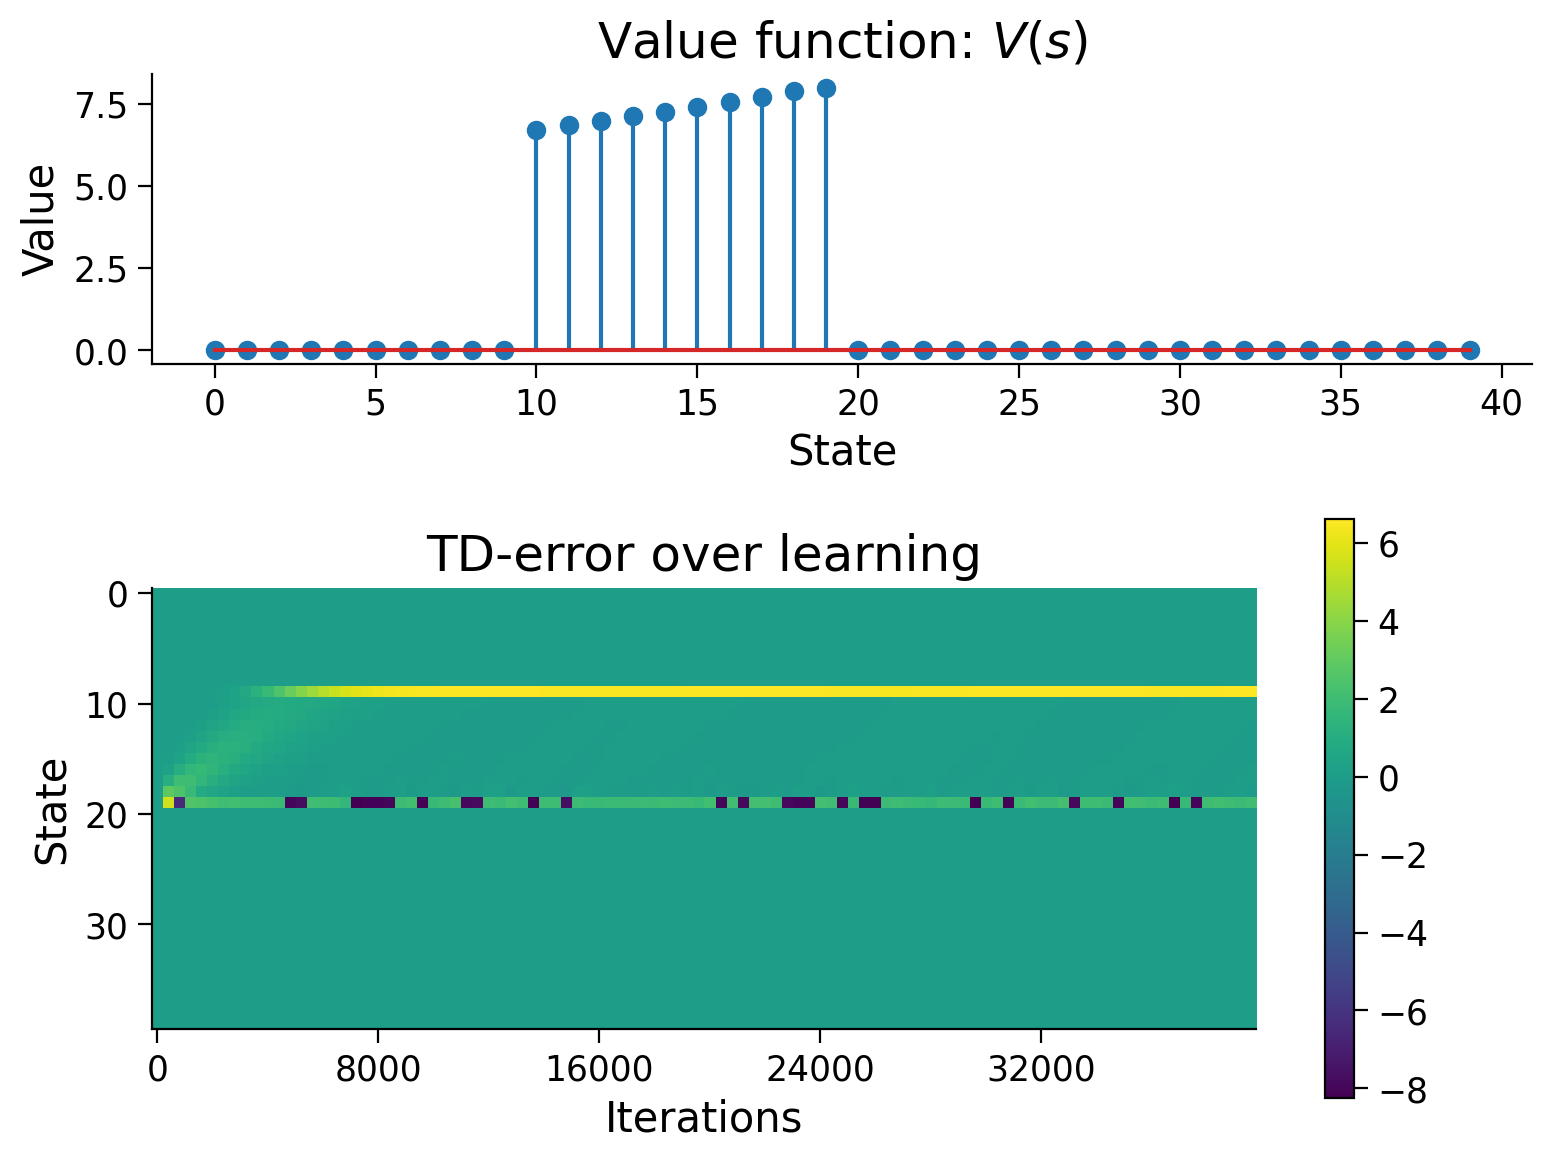

In [ ]:

# Execute this cell to visualize the value function and TD-errors when `alpha=0.002`
np.random.set_state(rng_state)  # Resynchronize everyone's notebooks
n_trials = 20000
try:
  env = ProbabilisticCC(n_steps=40, reward_magnitude=10, reward_time=10,
                        p_reward=0.8)
  V_stochastic, TDE_stochastic = td_learner(env, n_trials*2, alpha=.002)
  learning_summary_plot(V_stochastic, TDE_stochastic)
except NotImplementedError:
  print("Please finish Coding Exercise first")

# Question 5

1. What do you observe when the learning rate is high ($\alpha = 1$) and when the learning rate is low ($\alpha = 0.002$)? Which learning rate results in a value function that is more accurate and stable? Why?

2. When the reward is more uncertain, is it better to use a higher learning rate or lower learning rate? Why?


# Learning to act in a single state: the multi-armed bandits problem (operant conditioning)

## The multi-armed bandits task

Consider the following learning problem. You are faced repeatedly with a choice among $k$ different options, or actions. After each choice you receive a reward signal in the form of a numerical value, where the larger value is the better. Your objective is to maximize the expected total reward over some time period, for example, over 1000 action selections, or time steps.

This is the original form of the k-armed bandit problem. This name derives from the colloquial name for a slot machine, the "one-armed bandit", because it has the one lever to pull, and it is often rigged to take more money than it pays out over time. The multi-armed bandit extension is to imagine, for instance, that you are faced with multiple slot machines that you can play, but only one at a time. Which machine should you play, i.e., **which arm should you pull, which action should you take, at any given time to maximize your total payout.**

<img alt="MultiArmedBandit" width="625" height="269" src="https://github.com/NeuromatchAcademy/course-content/blob/main/tutorials/static/W3D4_Tutorial2_MultiarmedBandit.png?raw=true">

While there are many different levels of sophistication and assumptions in how the rewards are determined, we will consider here the simple scenario where each action results in a **reward** drawn from a different **Gaussian distribution with unknown mean and unit variance**. Since each action is associated with a different mean reward, the goal of the agent is to find the action with highest mean. But since the rewards are noisy (the corresponding Gaussians have unit variance), those means cannot be determined from a single observed reward.

This problem setting is referred to as the **environment**. We will solve this **optimization problem** with an **agent**, in this case an algorithm that takes in rewards and returns actions.

## Learning from rewards

How do we learn from our actions?

We need a way of describing our beliefs about the arms' reward potential. We do this with an **action-value function**:

\begin{equation}
q(a) = \mathbb{E} [r_{t} | a_{t} = a]
\end{equation}     

where the value $q$ for taking action $a \in A$ at time $t$ is equal to the expected value of the reward $r_t$ given that we took action $a$ at that time. In practice, $q$ is often represented as an array of values, where each action's value is a different element in the array.



One way to learn $q$ is just keep a record of every result we ever got and use the averages for each action. If we have a potentially very long running episode, the computational cost of keeping all these values and recomputing the mean over and over again isn't ideal. Instead we can use a streaming mean calculation, which looks like this:

$$
n_t q_{t+1}(a) = (n_t-1) q_t(a) + r
$$

$$
n_t q_{t+1}(a) = n_t q_t(a) + r - q_t(a)
$$

\begin{equation}
q_{t+1}(a) = q_{t}(a) + \frac{1}{n_t} (r_{t} - q_{t}(a))
\end{equation}

where our action-value function $q_t(a)$ is the mean of the rewards seen so far, $n_t$ is the number of times that the action $a$ has been taken by time $t$, and $r_t$ is the reward just received for taking action $a$.

This still requires us to remember how many actions we've taken, so let's generalize this a bit further and replace the action total with a general parameter $\alpha$, which we will call the learning rate:

\begin{equation}
q_{t+1}(a) = q_{t}(a) + \alpha (r_{t} - q_{t}(a))
\end{equation}



We will implement the action-value update rule above. The function will take in the action-value function represented as an array `q`, the action taken, the reward received, and the learning rate, `alpha`. The function will return the updated value for the selection action.

# Coding Exercise #2

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at line 22 and comment or remove the next line
raise NotImplementedError("Coding Exercise #2")
#############################################################################

def update_action_value(q, action, reward, alpha):
  """ Compute the updated action value given the learning rate and observed
  reward.

  Args:
    q (ndarray): an array of action values
    action (int): the action taken
    reward (float): the reward received for taking the action
    alpha (float): the learning rate

  Returns:
    float: the updated value for the selected action
  """

  # Write an expression for the updated action value
  value = ...

  return value


# Set parameters
q = [-2, 5, 0, 1]
action = 2
print(f"Original q({action}) value = {q[action]}")

# Update action
q[action] = update_action_value(q, 2, 10, 0.01)
print(f"Updated q({action}) value = {q[action]}")

Original q(2) value = 0
Updated q(2) value = 0.1


## Choosing an action: the exploitation-exploration trade-off

Our agent needs to be able to choose which arm to pull. The strategy for choosing actions based on our expectations is called a **policy** (often denoted $\pi$). We could have a random policy -- just pick an arm at random each time -- though this doesn't seem likely to be capable of optimizing our reward.

An obvious choice would be to take the action with the highest expected action-value. This is referred to as the **greedy** policy:

\begin{equation}
a_{t} = \underset{a}{\operatorname{argmax}} \; q_{t} (a)
\end{equation}

where our choice action is the one that maximizes the current action-value function.

So far so good, but it can't be this easy. And, in fact, the greedy policy does have a fatal flaw: it easily gets trapped in local maxima. It never explores to see what it hasn't seen before if one option is already better than the others. This leads us to a fundamental challenge in coming up with effective policies.

If we never try anything new, if we always stick to the safe bet, we don't know what we are missing. Sometimes we aren't missing much of anything, and regret not sticking with our preferred choice, yet other times we stumble upon something new that was way better than we thought.

This is the exploitation-exploration dilemma: do you go with your best choice now, or risk the less certain option with the hope of finding something better? Too much exploration, however, means you may end up with a sub-optimal reward once it's time to stop.

In order to avoid getting stuck in local minima while also maximizing reward, effective policies need some way to balance between these two aims. It is called **exploitation-exploration trade-off**.

## The epsilon-greedy policy  

If we never try anything new, if we always stick to the safe bet, we don't know what we are missing. Sometimes we aren't missing much of anything, and regret not sticking with our preferred choice, yet other times we stumble upon something new that was way better than we thought.

This is the exploitation-exploration dilemma: do you go with your best choice now, or risk the less certain option with the hope of finding something better? Too much exploration, however, means you may end up with a sub-optimal reward once it's time to stop.

In order to avoid getting stuck in local minima while also maximizing reward, effective policies need some way to balance between these two aims. It is called **exploitation-exploration trade-off**.



A simple extension to our greedy policy is to add some randomness. For instance, a coin flip -- heads we take the best choice now, tails we pick one at random. This is referred to as the **$\epsilon$-greedy policy**:

\begin{equation}
P (a_{t} = a) =
        \begin{cases}
        1 - \epsilon + \epsilon/N    & \quad \text{if } a_{t} = \underset{a}{\operatorname{argmax}}  \; q_{t} (a) \\
        \epsilon/N        & \quad \text{else}
        \end{cases}
\end{equation}

which is to say that with probability 1 - $\epsilon$ for $\epsilon \in [0,1]$ we select the greedy choice, and otherwise we select an action at random (including the greedy option).

Despite its relative simplicity, the epsilon-greedy policy is quite effective, which leads to its general popularity.

### Implement the epsilon-greedy policy

We will implement the epsilon-greedy algorithm for deciding which action to take from a set of possible actions given their value function and a probability $\epsilon$ of simply choosing one at random.

TIP: You may find [`np.random.random`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random.html), [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html), and [`np.argmax`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) useful here.

# Coding Exercise #3

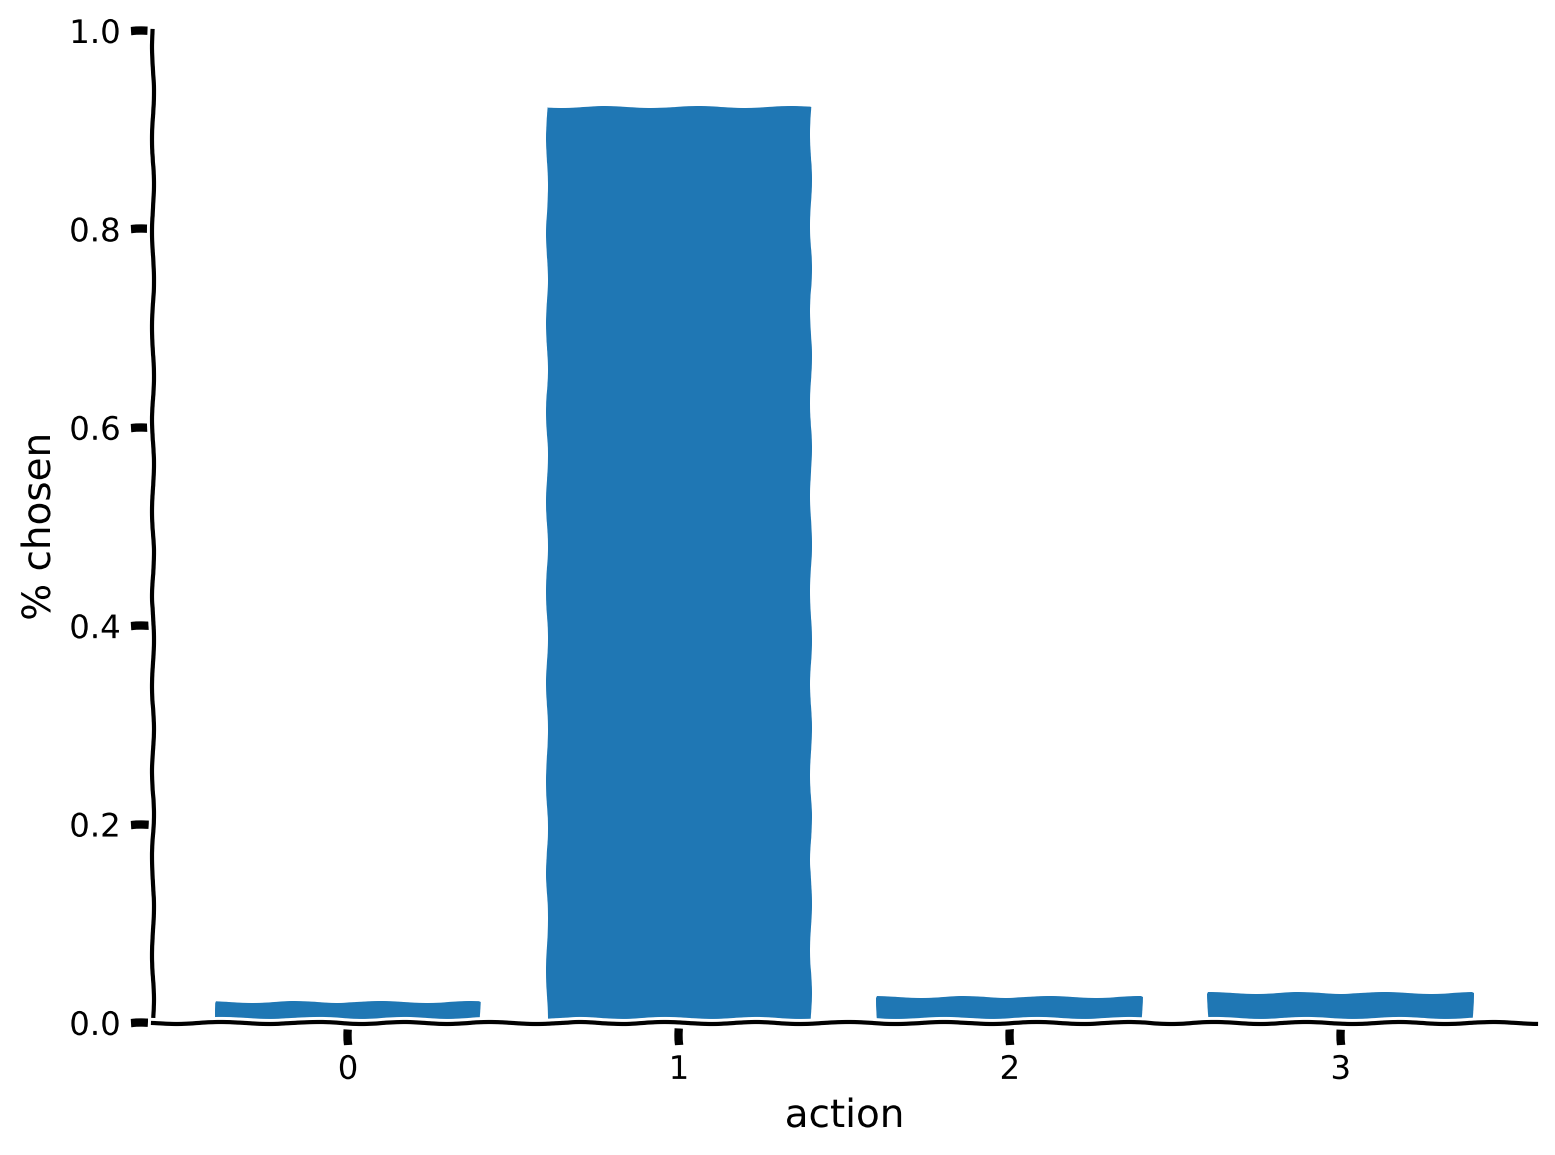

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at lines 24, 29 and comment or remove the next line
raise NotImplementedError("Coding Exercise #3")
#############################################################################

def epsilon_greedy(q, epsilon):
  """Epsilon-greedy policy: selects the maximum value action with probability
  (1-epsilon) and selects randomly with epsilon probability.

  Args:
    q (ndarray): an array of action values
    epsilon (float): probability of selecting an action randomly

  Returns:
    int: the chosen action
  """
  # write a boolean expression that determines if we should take the best action
  be_greedy = np.random.random() > epsilon

  if be_greedy:

    # write an expression for selecting the best action from the action values
    action = ...

  else:

    # write an expression for selecting a random action
    action = ...

  return action


# Set parameters
q = [-2, 5, 0, 1]
epsilon = 0.1

# Visualize
with plt.xkcd():
  plot_choices(q, epsilon, epsilon_greedy)


This is what we should expect, that the action with the largest value (action 1) is selected about (1-$\epsilon$) of the time, or 90% for $\epsilon = 0.1$, and the remaining 10% is split evenly amongst the other options. Use the demo below to explore how changing $\epsilon$ affects the distribution of selected actions.

### Interactive Demo: Changing Epsilon

Epsilon is our one parameter for balancing exploitation and exploration.  Given a set of values $q = [-2, 5, 0, 1]$, use the widget below to see how changing $\epsilon$ influences our selection of the max value 5 (action = 1) vs the others.

At the extremes of its range (0 and 1), the $\epsilon$-greedy policy reproduces two other policies. What are they?

In [ ]:

@widgets.interact(epsilon=widgets.FloatSlider(0.1, min=0.0, max=1.0,
                                              description="ε"))
def explore_epilson_values(epsilon=0.1):
  q = [-2, 5, 0, 1]
  plot_choices(q, epsilon, epsilon_greedy, rng_seed=None)

interactive(children=(FloatSlider(value=0.1, description='ε', max=1.0), Output()), _dom_classes=('widget-inter…

## Solving the multi-armed bandits problem with the epsilon-greedy policy

Now that we have both a policy and a learning rule, we can combine these to solve our original multi-armed bandit task. Recall that we have some number of arms that give **rewards drawn from Gaussian distributions with unknown mean and unit variance**, and our goal is to **find the arm with the highest mean**.

# Coding Exercise #4

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at line 37 and comment or remove the next line
raise NotImplementedError("Coding Exercise #4")
#############################################################################

def multi_armed_bandit(n_arms, epsilon, alpha, n_steps):
  """ A Gaussian multi-armed bandit using an epsilon-greedy policy. For each
  action, rewards are randomly sampled from normal distribution, with a mean
  associated with that arm and unit variance.

  Args:
    n_arms (int): number of arms or actions
    epsilon (float): probability of selecting an action randomly
    alpha (float): the learning rate
    n_steps (int): number of steps to evaluate

  Returns:
    dict: a dictionary containing the action values, actions, and rewards from
    the evaluation along with the true arm parameters mu and the optimality of
    the chosen actions.
  """
  # Gaussian bandit parameters
  mu = np.random.normal(size=n_arms)

  # Evaluation and reporting state
  q = np.zeros(n_arms)
  qs = np.zeros((n_steps, n_arms))
  rewards = np.zeros(n_steps)
  actions = np.zeros(n_steps)
  optimal = np.zeros(n_steps)

  # Run the bandit
  for t in range(n_steps):

    # Choose an action
    action = ... # Choose an action using the epsilon greedy policy
    actions[t] = action

    # Compute rewards for all actions
    all_rewards = np.random.normal(mu)

    # Observe the reward for the chosen action
    reward = all_rewards[action]
    rewards[t] = reward

    # Was it the best possible choice?
    optimal_action = np.argmax(all_rewards)
    optimal[t] = action == optimal_action

    # Update the action value
    q[action] = update_action_value(q, action, reward, alpha)
    qs[t] = q

  results = {
      'qs': qs,
      'actions': actions,
      'rewards': rewards,
      'mu': mu,
      'optimal': optimal
  }

  return results

We can use our multi-armed bandit method to evaluate how our epsilon-greedy policy and learning rule perform at solving the task. First we will set our environment to have 10 arms and our agent parameters to $\epsilon=0.1$ and $\alpha=0.01$. In order to get a good sense of the agent's performance, we will run the episode for 1000 steps.

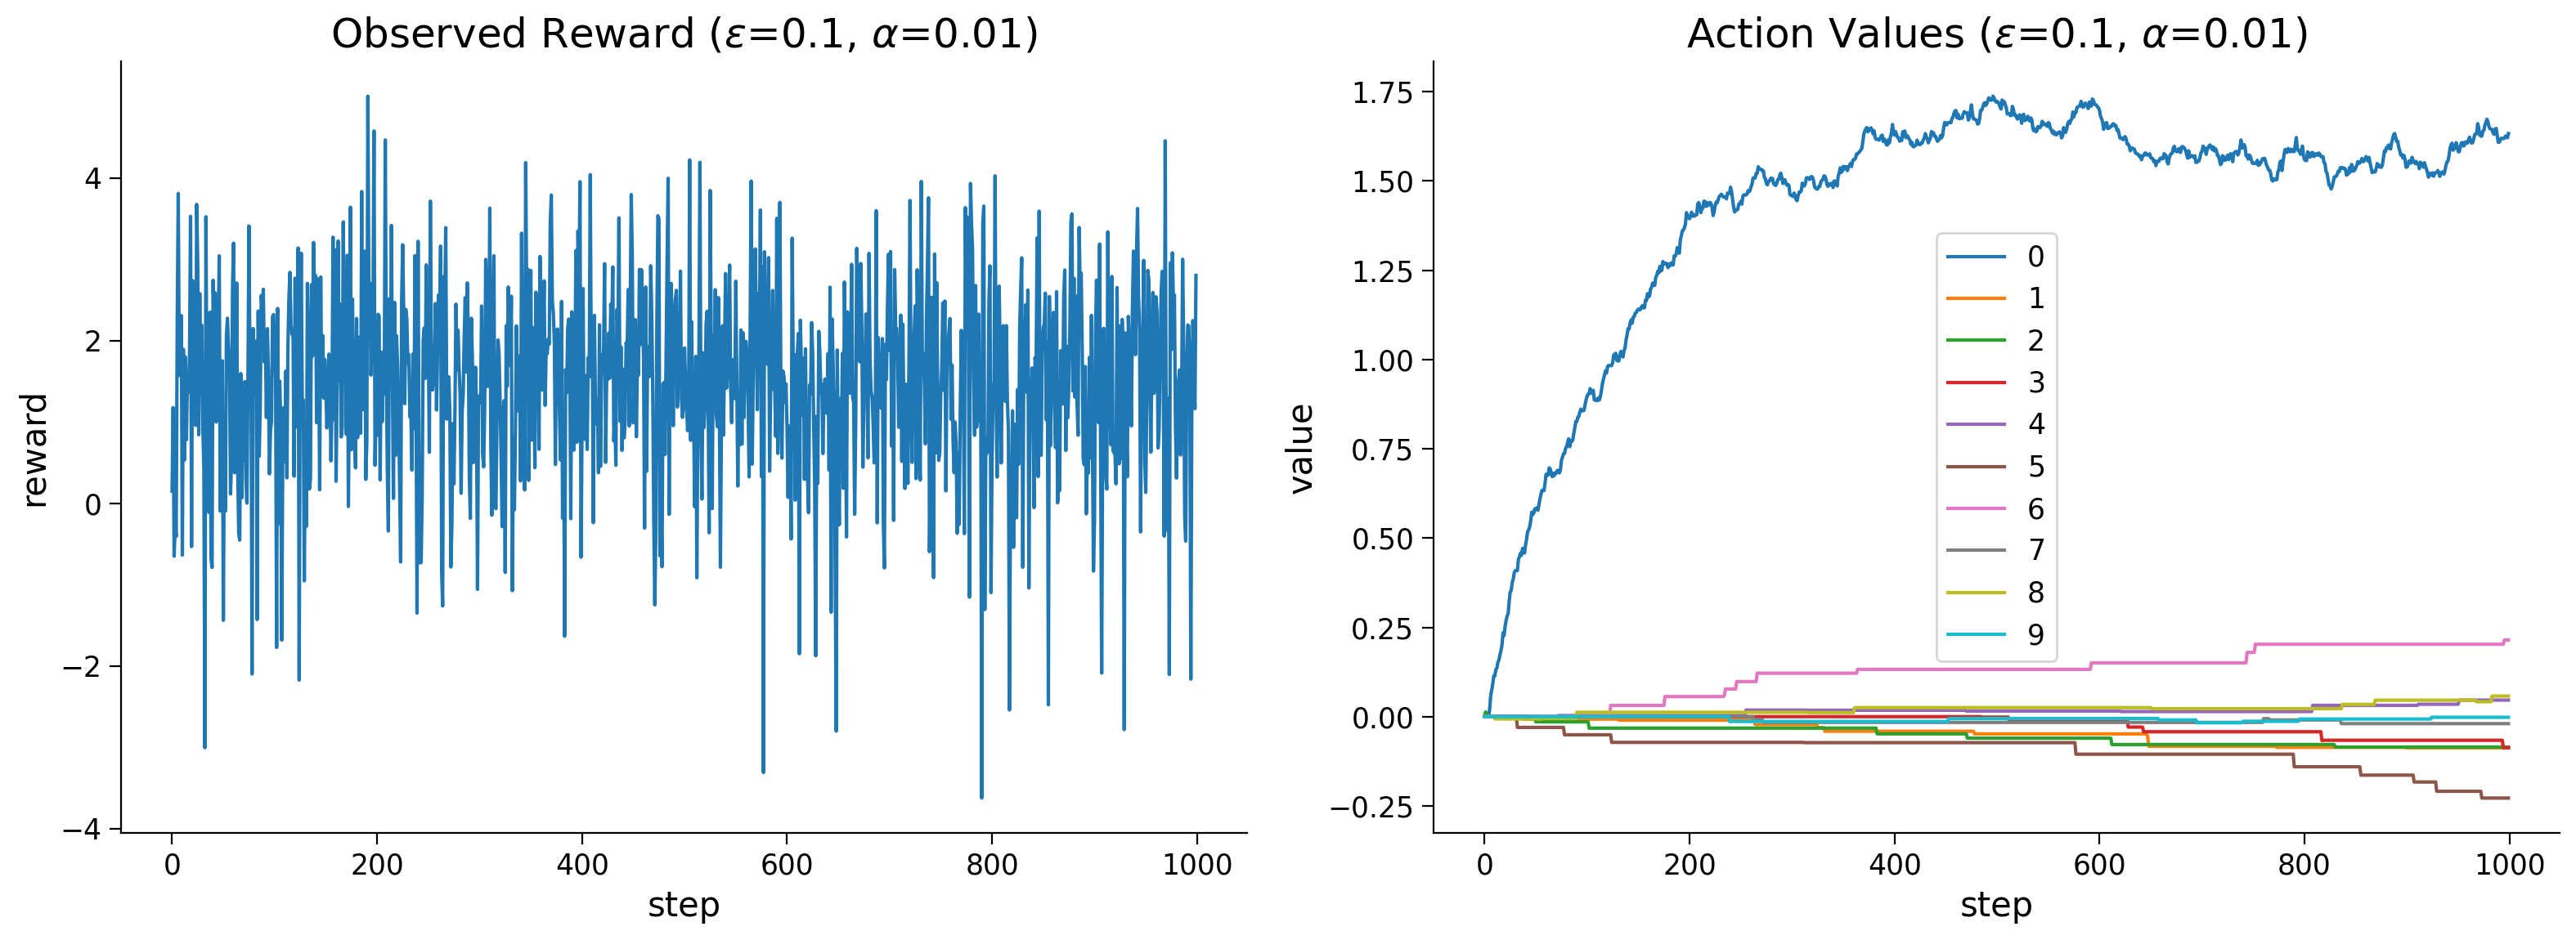

actual rewards for different arms:  [ 1.624 -0.612 -0.528 -1.073  0.865 -2.302  1.745 -0.761  0.319 -0.249]


In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

n_arms = 10
epsilon = 0.1
alpha = 0.01
n_steps = 1000

results = multi_armed_bandit(n_arms, epsilon, alpha, n_steps)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
ax1.plot(results['rewards'])
ax1.set(title=f'Observed Reward ($\epsilon$={epsilon}, $\\alpha$={alpha})',
        xlabel='step', ylabel='reward')
ax2.plot(results['qs'])
ax2.set(title=f'Action Values ($\epsilon$={epsilon}, $\\alpha$={alpha})',
        xlabel='step', ylabel='value')
ax2.legend(range(n_arms))
plt.show(fig)

print("actual rewards for different arms: ", results['mu'])

We got some rewards that are kind of all over the place, but the agent seemed to settle in on the first arm as the preferred choice of action relatively quickly. Let's see how well we did at recovering the true means of the Gaussian random variables behind the arms.

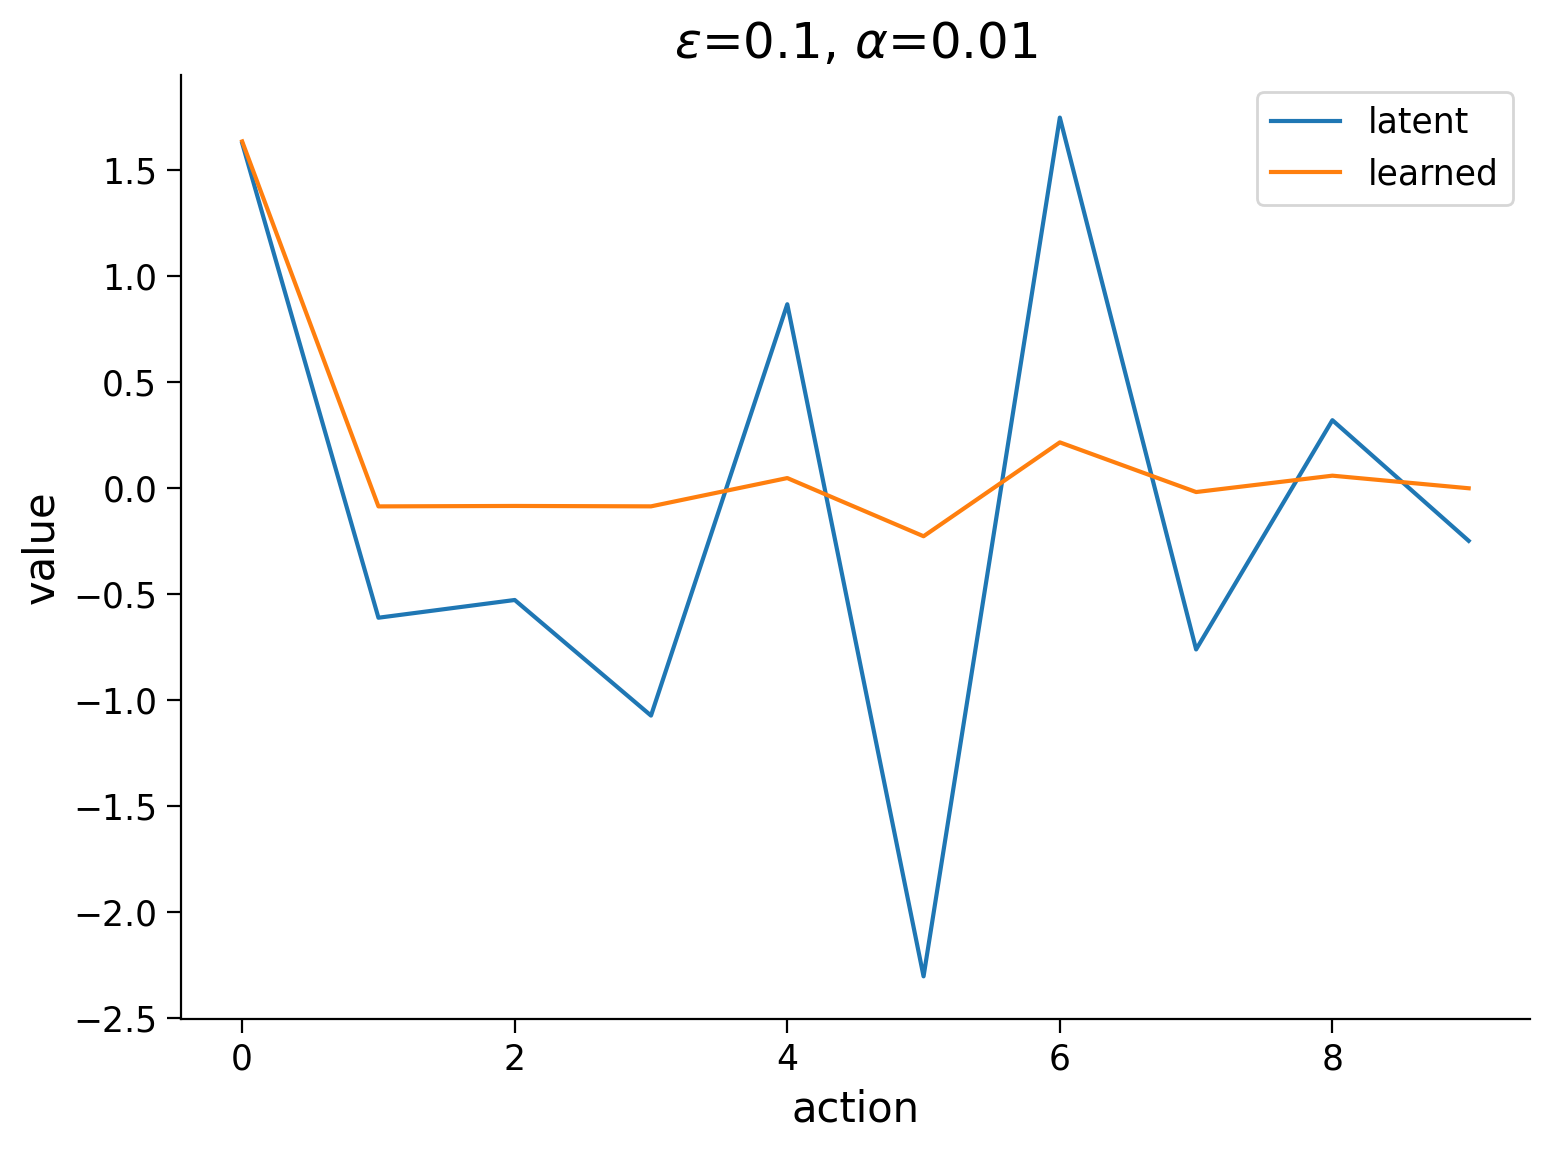

actual rewards for different arms:  [ 1.624 -0.612 -0.528 -1.073  0.865 -2.302  1.745 -0.761  0.319 -0.249]


In [ ]:

fig, ax = plt.subplots()
ax.plot(results['mu'], label='latent')
ax.plot(results['qs'][-1], label='learned')
ax.set(title=f'$\epsilon$={epsilon}, $\\alpha$={alpha}',
       xlabel='action', ylabel='value')
ax.legend()
plt.show(fig)
print("actual rewards for different arms: ", results['mu'])


Well, we seem to have found a very good estimate for action 0, but most of the others are not great. In fact, we can see the effect of the local maxima trap at work -- the greedy part of our algorithm locked onto action 0, which is actually the 2nd best choice to action 6. Since these are the means of Gaussian random variables, we can see that the overlap between the two would be quite high, so even if we did explore action 6, we may draw a sample that is still lower than our estimate for action 0.

However, this was just one choice of parameters. Perhaps there is a better combination?

### Interactive Demo: Changing Epsilon and Alpha

Use the widget below to explore how varying the values of $\epsilon$ (exploitation-exploration trade-off), $\alpha$ (learning rate), and even the number of actions $k$, changes the behavior of our agent.

In [ ]:

@widgets.interact_manual(k=widgets.IntSlider(10, min=2, max=15),
                         epsilon=widgets.FloatSlider(0.1, min=0.0, max=1.0,
                                                     description="ε"),
                         alpha=widgets.FloatLogSlider(0.01, min=-3, max=0,
                                                      description="α"))
def explore_bandit_parameters(k=10, epsilon=0.1, alpha=0.001):
  results = multi_armed_bandit(k, epsilon, alpha, 1000)
  plot_multi_armed_bandit_results(results)
  print("actual rewards for different arms: ", results['mu'])


interactive(children=(IntSlider(value=10, description='k', max=15, min=2), FloatSlider(value=0.1, description=…

While we can see how changing the epsilon and alpha values impact the agent's behavior, this doesn't give us a great sense of which combination is optimal. Due to the stochastic nature of both our rewards and our policy, a single trial run isn't sufficient to give us this information. Let's run multiple trials and compare the average performance.

First we will look at different values for $\epsilon \in [0.0, 0.1, 0.2]$ to a fixed $\alpha=0.1$. We will run 200 trials as a nice balance between speed and accuracy.

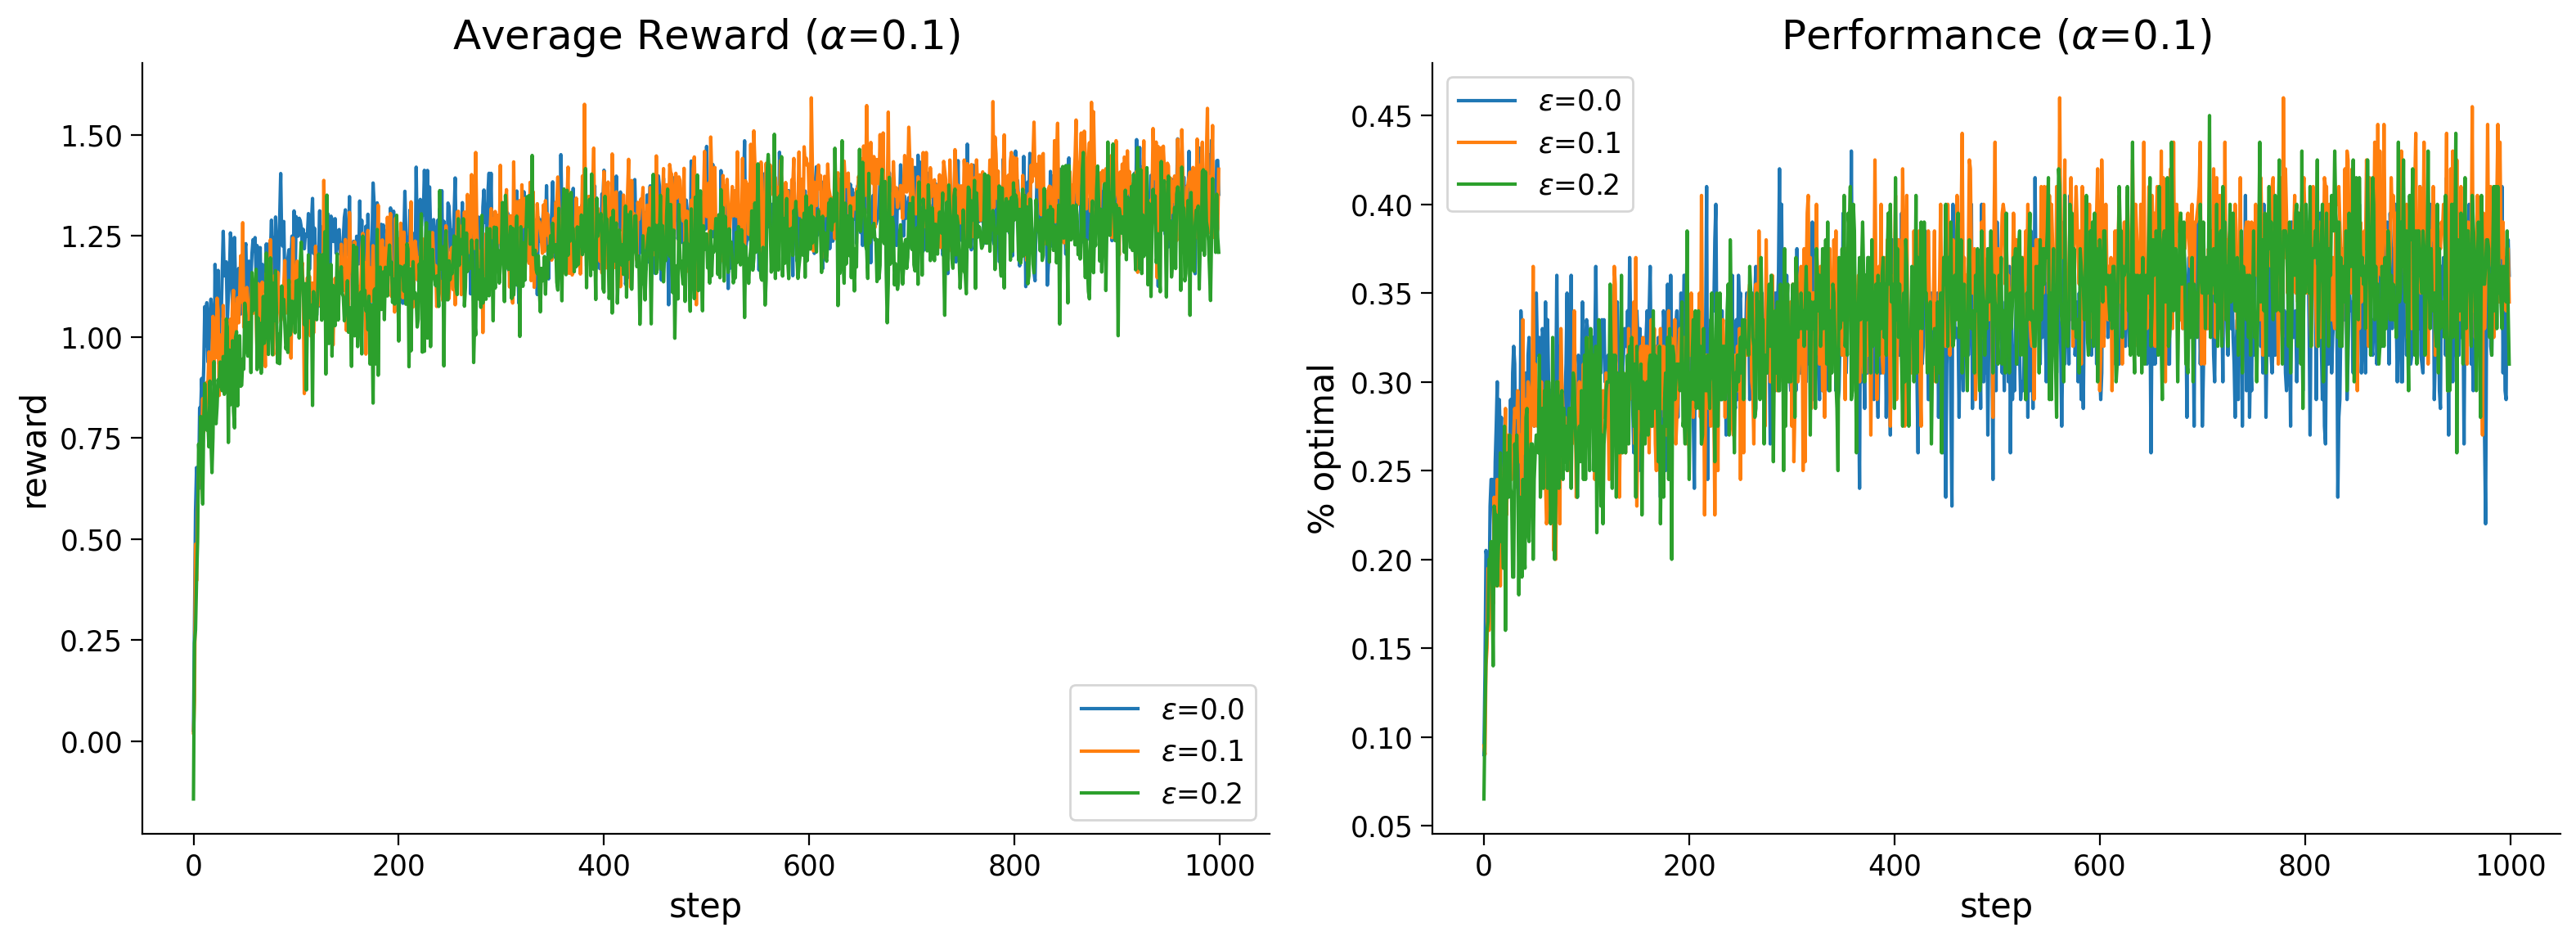

In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

epsilons = [0.0, 0.1, 0.2]
alpha = 0.1
n_trials = 200
trial_rewards = np.zeros((len(epsilons), n_trials, n_steps))
trial_optimal = np.zeros((len(epsilons), n_trials, n_steps))
for i, epsilon in enumerate(epsilons):
  for n in range(n_trials):
    results = multi_armed_bandit(n_arms, epsilon, alpha, n_steps)
    trial_rewards[i, n] = results['rewards']
    trial_optimal[i, n] = results['optimal']

labels = [f'$\epsilon$={e}' for e in epsilons]
fixed = f'$\\alpha$={alpha}'
plot_parameter_performance(labels, fixed, trial_rewards, trial_optimal)



On the left we have plotted the average reward over time, and we see that while $\epsilon=0$ (the greedy policy) does well initially, $\epsilon=0.1$ starts to do slightly better in the long run, while $\epsilon=0.2$ does the worst. Looking on the right, we see the percentage of times the optimal action (the best possible choice at time $t$) was taken, and here again we see a similar pattern of $\epsilon=0.1$ starting out a bit slower but eventually having a slight edge in the longer run.

We can also do the same for the learning rates. We will evaluate $\alpha \in [0.01, 0.1, 1.0]$ to a fixed $\epsilon=0.1$.

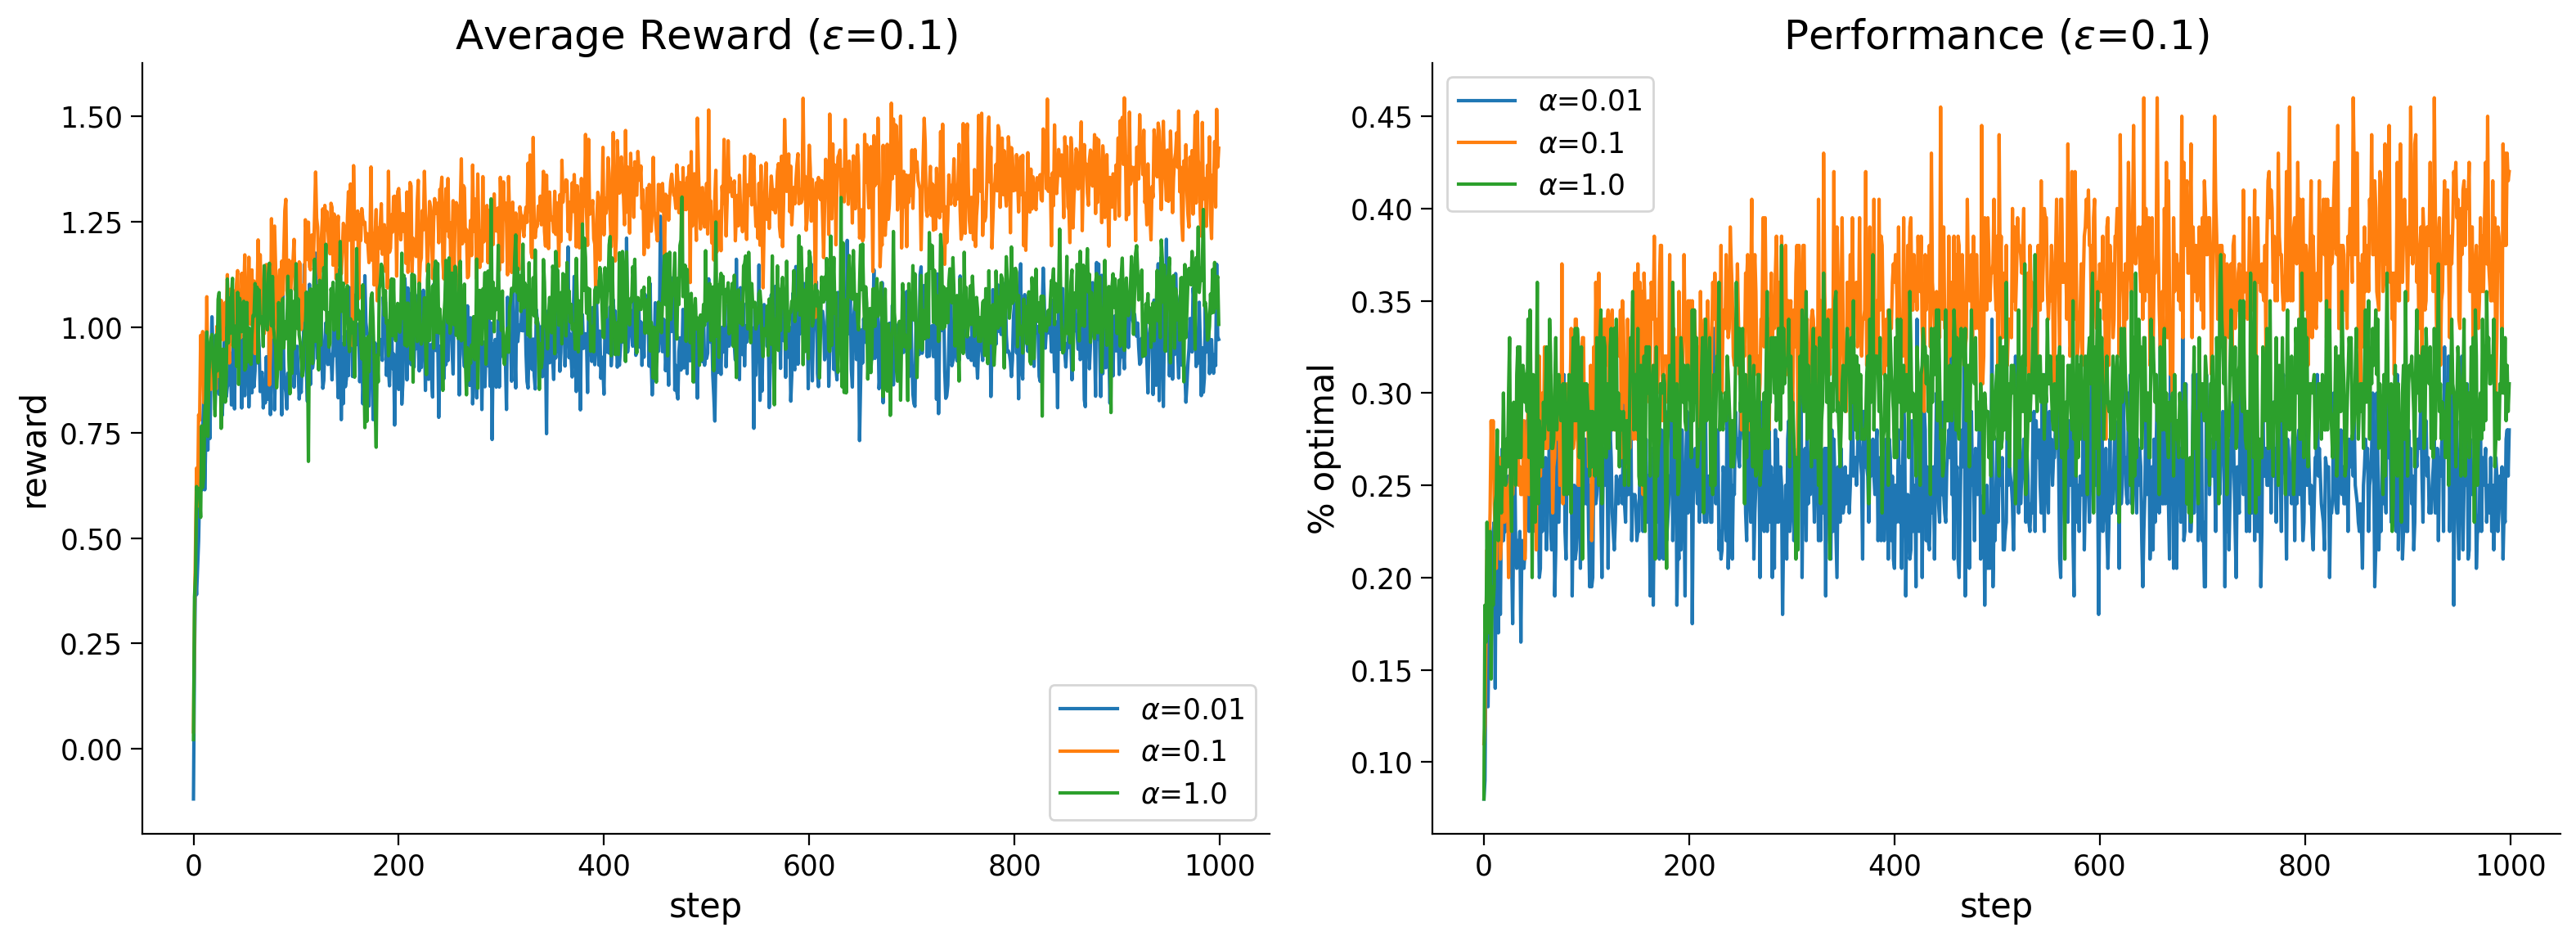

In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

epsilon = 0.1
alphas = [0.01, 0.1, 1.0]
n_trials = 200
trial_rewards = np.zeros((len(epsilons), n_trials, n_steps))
trial_optimal = np.zeros((len(epsilons), n_trials, n_steps))
for i, alpha in enumerate(alphas):
  for n in range(n_trials):
    results = multi_armed_bandit(n_arms, epsilon, alpha, n_steps)
    trial_rewards[i, n] = results['rewards']
    trial_optimal[i, n] = results['optimal']

labels = [f'$\\alpha$={a}' for a in alphas]
fixed = f'$\epsilon$={epsilon}'
plot_parameter_performance(labels, fixed, trial_rewards, trial_optimal)



Again we see a balance between an effective learning rate. $\alpha=0.01$ is too weak to quickly incorporate good values, while $\alpha=1$ is too strong likely resulting in high variance in values due to the Gaussian nature of the rewards.

## The upper confidence bound (UCB) policy

The **Upper Confidence Bound (UCB)** policy is another decision-making policy that is used to balance **exploration** (testing uncertain options) and **exploitation** (choosing the best-known option).

For an arm $ i $, a **UCB score** is calculated as:

$$
\text{UCB}_i = \hat{\mu_i} + c \left(\frac{\ln t}{n_i}\right)^{\frac{1}{2}}
$$

where:
- $ \hat{\mu_i} $: Empirical mean reward of arm $ i $ (action-value).
- $ c $: Exploration parameter controlling the balance between exploration and exploitation.
- $ t $: Current time step (total number of pulls).
- $ n_i $: Number of times arm $ i $ has been pulled.

**At each time step, the UCB policy select the arm with the highest UCB score.**



The UCB score combines two components:
1. **Empirical Mean Reward**: It is the average reward obtained from an arm so far.
2. **Confidence Interval**: It is the uncertainty about the arm's reward.




UCB is calculated in the above way so that:

1. Empirical Mean $ \hat{\mu_i} $ (action-value):

   It encourages selecting arms with higher average observed rewards **(exploitation)**.
2. Confidence Interval $ c \left(\frac{\ln t}{n_i}\right)^{\frac{1}{2}} $:

   It encourages selecting arms with higher uncertainty. As a result, UCB prefer arms that have been selected less often because they have higher uncertainty **(exploration)**.
3. Logarithmic Growth $ \ln t $:

   It ensures exploration will decrease over time as more information is gathered from each arm. It is because the linear growth of $n_i$ in the denominator is faster than the logarithmic growth of $\ln t$ in the numerator. **(more exploration at the beginning, more exploitation later on)**


Therefore, UCB automatically balances exploring new options and exploiting known good ones.




### Implement the upper confidence bound (UCB) policy

Let us implement UCB with the code below for deciding which action to take from a set of possible actions given their value function

# Coding Exercise #5

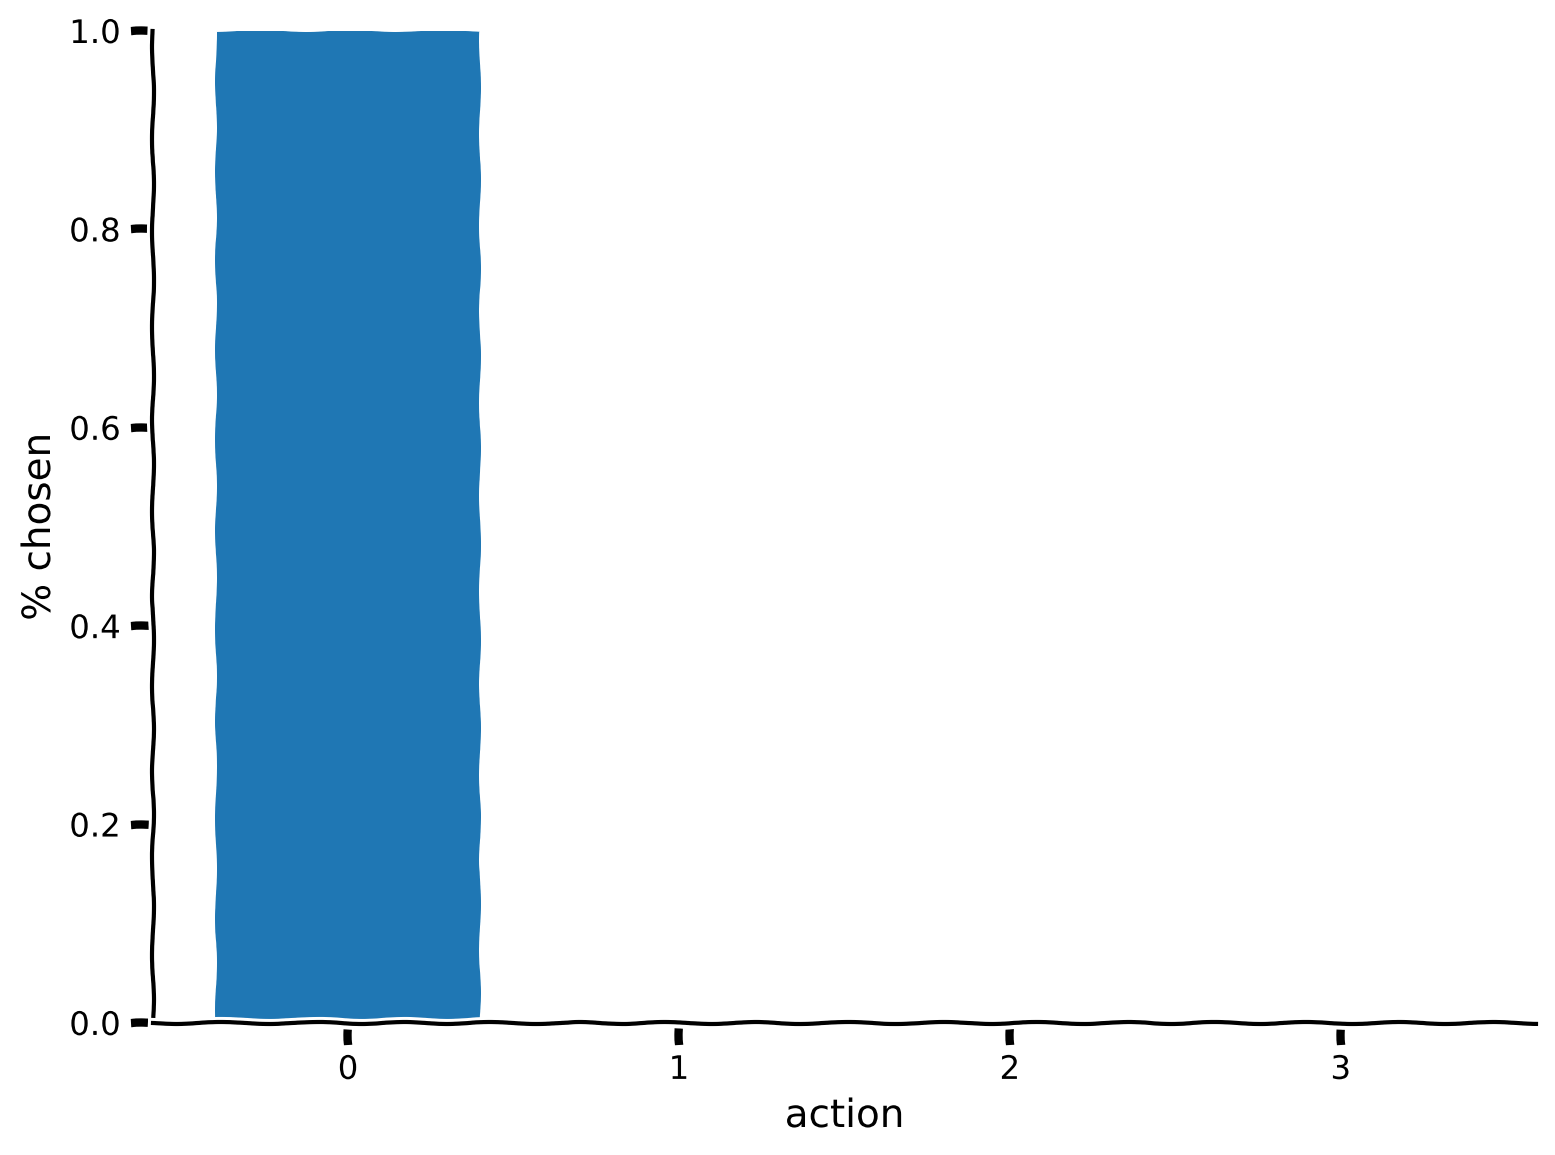

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at lines 27 - 29 and comment or remove the next line
raise NotImplementedError("Coding Exercise #5")
#############################################################################

def ucb(q, c, n_i):
  """upper confidence bound (UCB) policy: selects the action with the highest UCB score.

  Args:
    q (ndarray): an array of action values
    c (float): exploration parameter controlling the balance between exploration and exploitation
    n_i (ndarray): an array of the number of times that each action is selected

  Returns:
    int: the chosen action
  """

  t = np.sum(n_i)
  n_actions = len(q)

  ucb_values = np.zeros(n_actions)
  for action in range(n_actions):
      if n_i[action] == 0:
          ucb_values[action] = float('inf')  # Force exploration
      else:
          mean_reward = ...
          confidence_interval = ...
          ucb_values[action] = ...

  action = np.argmax(ucb_values)

  return action


# Set parameters
q = [-2, 5, 0, 1]
c = np.sqrt(2)
n_i = [0,1,2,3]

# Visualize
with plt.xkcd():
  plot_choices_ucb(q, c, n_i, ucb)

# Question 6

Is the result shown above what we should expect when the value for each choice is `q = [-2, 5, 0, 1]` and the number of times that each action selected is `n_i = [0,1,2,3]`? Why?

## Solving the multi-armed bandits problem with the upper confidence bound (UCB) policy

We can use the upper confidence bound (UCB) policy to solve multi-armed bandits problem and compare it with the epsilon-greedy policy.

First, we need to write a function `multi_armed_bandit_ucb` to compute the action to be selected using UCB:

# Coding Exercise #6

In [ ]:

#############################################################################
# Students: Fill in missing code (...) at line 38 and comment or remove the next line
raise NotImplementedError("Coding Exercise #6")
#############################################################################

def multi_armed_bandit_ucb(n_arms, c, alpha, n_steps):
  """ A Gaussian multi-armed bandit using an upper confidence bound policy. For each
  action, rewards are randomly sampled from normal distribution, with a mean
  associated with that arm and unit variance.

  Args:
    n_arms (int): number of arms or actions
    c (float): exploration parameter controlling the balance between exploration and exploitation
    alpha (float): the learning rate
    n_steps (int): number of steps to evaluate

  Returns:
    dict: a dictionary containing the action values, actions, and rewards from
    the evaluation along with the true arm parameters mu and the optimality of
    the chosen actions.
  """
  # Gaussian bandit parameters
  mu = np.random.normal(size=n_arms)

  # Evaluation and reporting state
  q = np.zeros(n_arms)
  qs = np.zeros((n_steps, n_arms))
  rewards = np.zeros(n_steps)
  actions = np.zeros(n_steps)
  optimal = np.zeros(n_steps)
  n_i = np.zeros(n_arms)

  # Run the bandit
  for t in range(n_steps):

    # Choose an action
    action = ...      # Choose an action using UCB policy
    actions[t] = action
    n_i[action] = n_i[action] + 1

    # Compute rewards for all actions
    all_rewards = np.random.normal(mu)

    # Observe the reward for the chosen action
    reward = all_rewards[action]
    rewards[t] = reward

    # Was it the best possible choice?
    optimal_action = np.argmax(all_rewards)
    optimal[t] = action == optimal_action

    # Update the action value
    q[action] = update_action_value(q, action, reward, alpha)
    qs[t] = q

  results = {
      'qs': qs,
      'actions': actions,
      'rewards': rewards,
      'mu': mu,
      'optimal': optimal
  }

  return results

Next, we can try solving the multi armed bandit task with UCB.

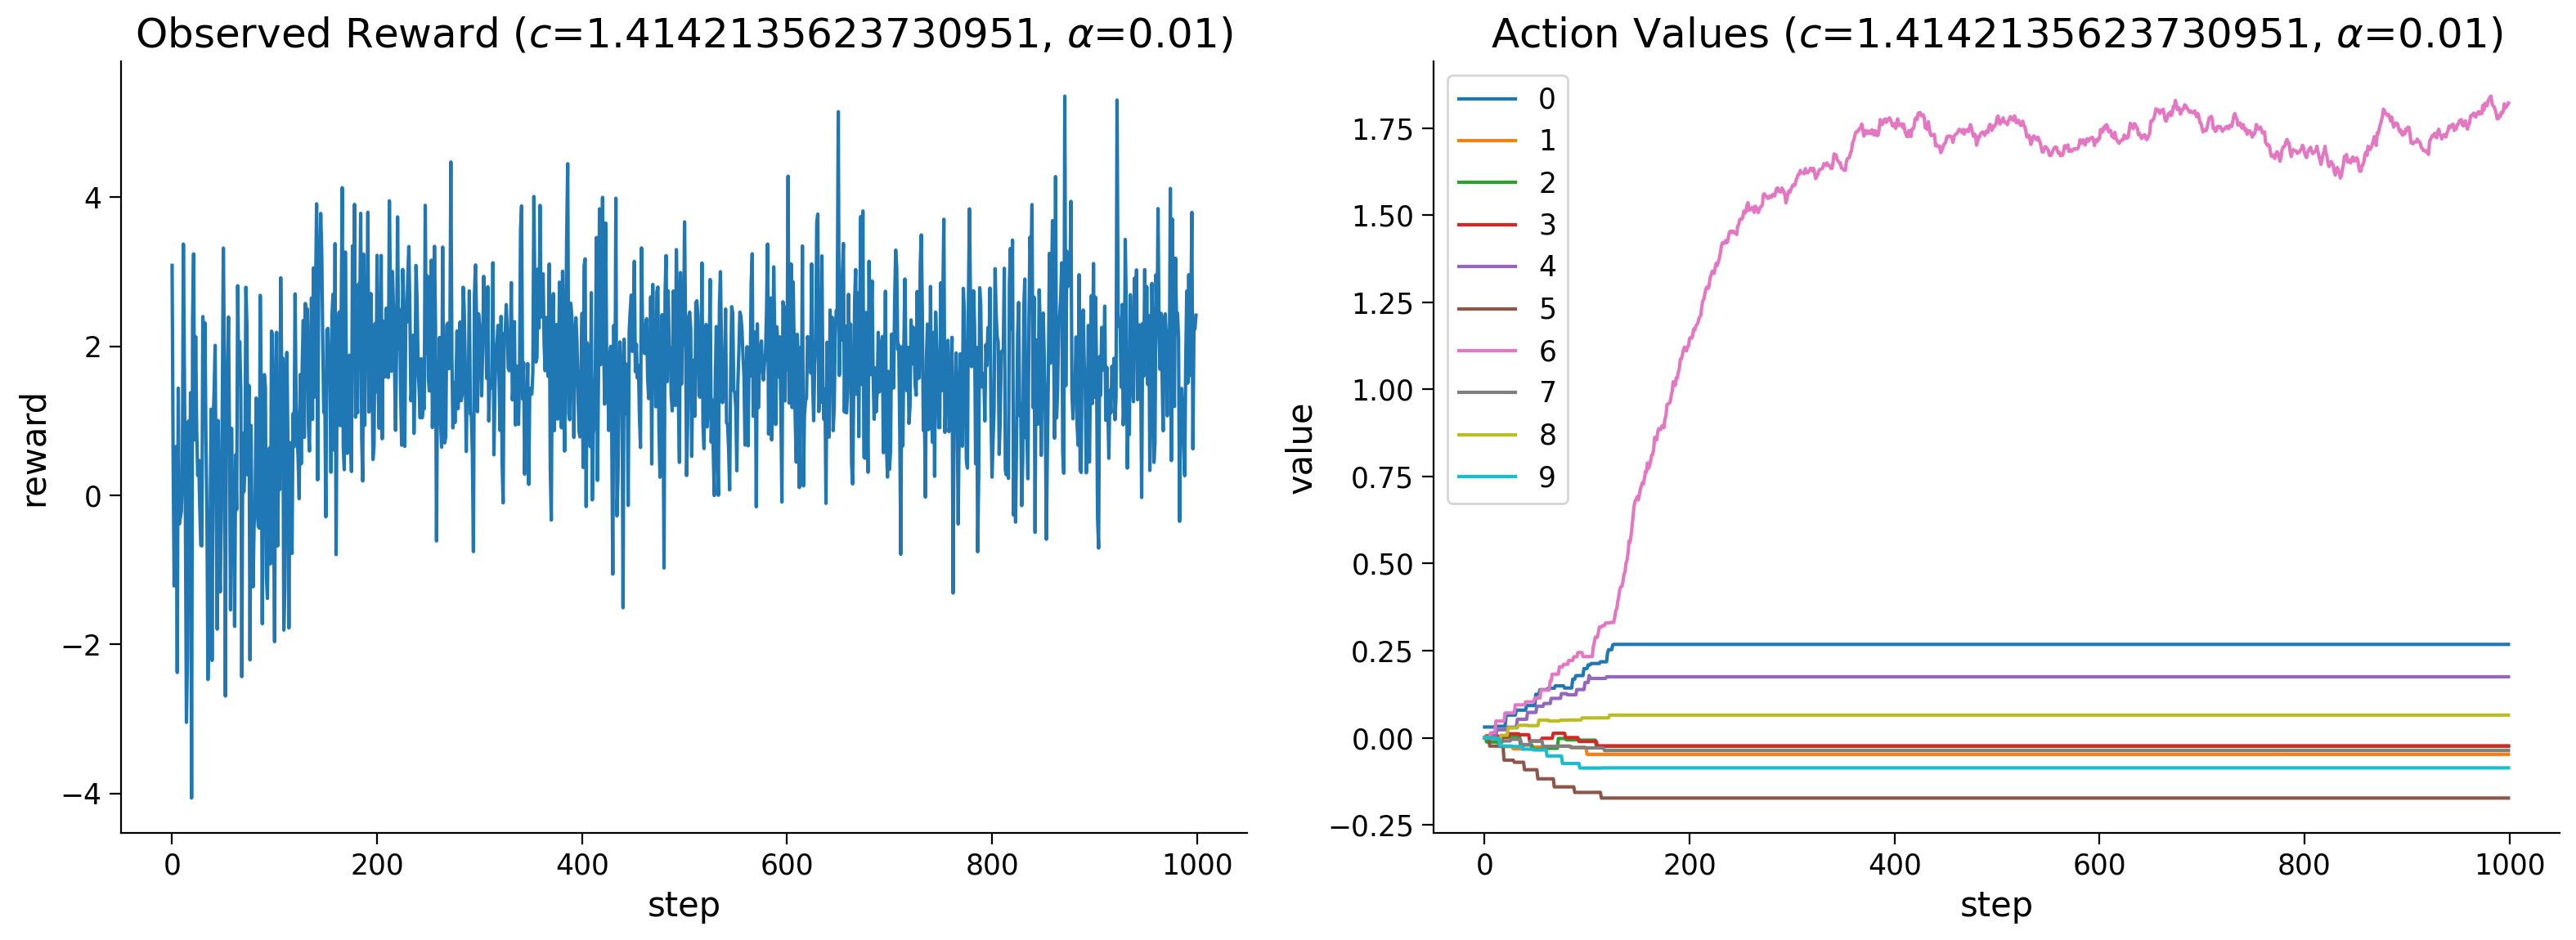

actual rewards for different arms:  [ 1.624 -0.612 -0.528 -1.073  0.865 -2.302  1.745 -0.761  0.319 -0.249]


In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

n_arms = 10
c = np.sqrt(2)
alpha = 0.01
n_steps = 1000

results = multi_armed_bandit_ucb(n_arms, c, alpha, n_steps)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
ax1.plot(results['rewards'])
ax1.set(title=f'Observed Reward ($c$={c}, $\\alpha$={alpha})',
        xlabel='step', ylabel='reward')
ax2.plot(results['qs'])
ax2.set(title=f'Action Values ($c$={c}, $\\alpha$={alpha})',
        xlabel='step', ylabel='value')
ax2.legend(range(n_arms))
plt.show(fig)

print("actual rewards for different arms: ", results['mu'])

We got some rewards that are kind of all over the place, and the agent seemed to settle in on the sixth arm as the preferred choice of action relatively quickly. Let's see how well we did at recovering the true means of the Gaussian random variables behind the arms.

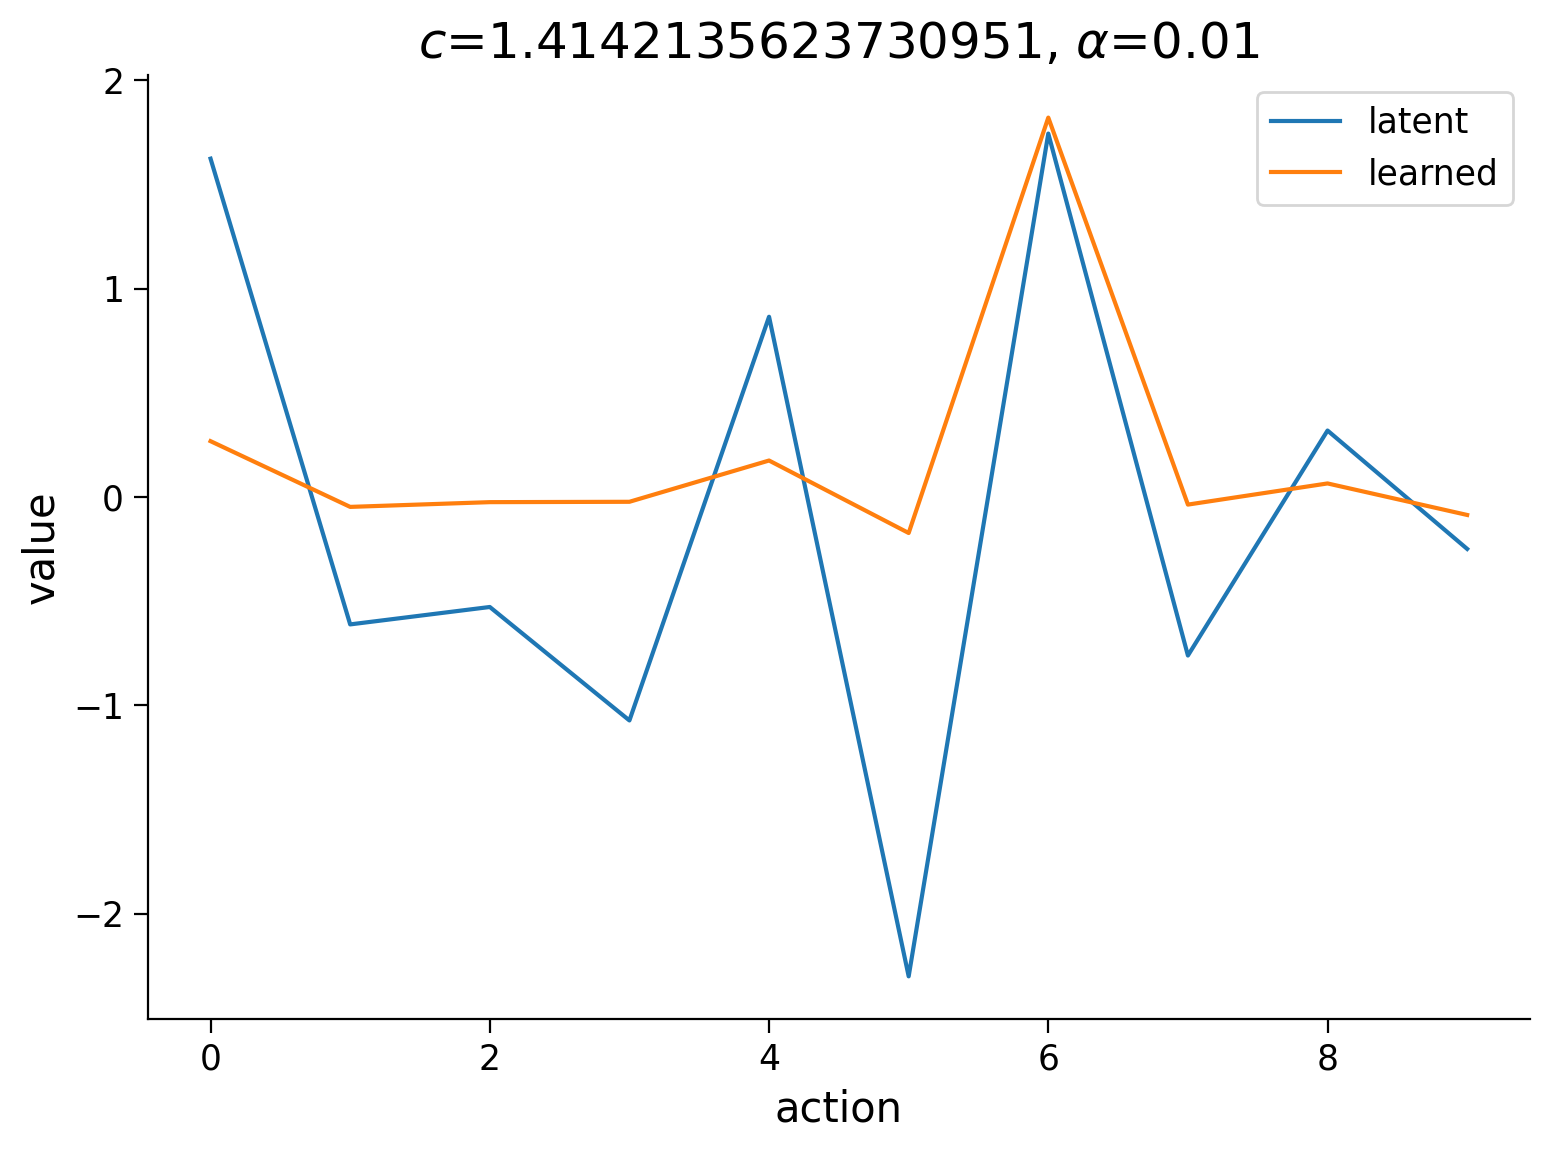

actual rewards for different arms:  [ 1.624 -0.612 -0.528 -1.073  0.865 -2.302  1.745 -0.761  0.319 -0.249]


In [ ]:

fig, ax = plt.subplots()
ax.plot(results['mu'], label='latent')
ax.plot(results['qs'][-1], label='learned')
ax.set(title=f'$c$={c}, $\\alpha$={alpha}',
       xlabel='action', ylabel='value')
ax.legend()
plt.show(fig)

print("actual rewards for different arms: ", results['mu'])

We seem to have found a very good estimate for action 6, but most of the others are not great. This time with UCB, we can see our algorithm did not lock onto action 0, it correctly found that the  best choice is action 6.

Is UCB also sensitive to different parameter choices? We can use the following interactive domo to try it out:

### Interactive Demo: Changing $c$ and Alpha

In [ ]:

@widgets.interact_manual(k=widgets.IntSlider(10, min=2, max=15),
                         c=widgets.FloatSlider(np.sqrt(2), min=0.0, max=5.0,
                                                     description="c"),
                         alpha=widgets.FloatLogSlider(0.01, min=-3, max=0,
                                                      description="α"))
def explore_bandit_parameters(k=10, c=1, alpha=0.01):
  results = multi_armed_bandit_ucb(k, c, alpha, 1000)
  plot_multi_armed_bandit_results(results)
  print("actual rewards for different arms: ", results['mu'])


interactive(children=(IntSlider(value=10, description='k', max=15, min=2), FloatSlider(value=1.414213562373095…

## UCB may be a powerful alternative to A/B testing

### What is A/B testing?

**A/B testing**, also known as split testing, is a method used to compare two versions of a webpage, app, email, or other content to determine which one performs better for a specific goal. It is commonly used in marketing, product development, and user experience (UX) design to make data-driven decisions.

**How A/B Testing Works:**

1. Create Two Variants:

 Version A (Control): The original version or current standard.

 Version B (Variation): A modified version with one or more changes.

2. Define a Metric:

 Choose a key performance indicator (KPI) to measure success, such as click-through rate, conversion rate, bounce rate, or revenue.

3. Divide the Participants:

 Randomly split your participants into two groups: one sees Version A, and the other sees Version B.

4. Run the Experiment:

 Present the two versions simultaneously to their respective groups under the same conditions.

5. Collect Data:

 Track how each group interacts with the content based on the predefined metric.

6. Analyze Results:

 Use statistical methods to determine if the differences in performance between A and B are significant.

Example:

A company wants to improve its website's conversion rate (e.g. the percentage of visitors who sign up on the website). They design two different versions of a call-to-action button:

Version A: "Sign Up Now" (blue button).

Version B: "Join Us Today" (green button). After running the test for a few days, they find that Version B has a 15% higher conversion rate. They can then implement Version B for all users.

**A/B testing is an essential tool for optimizing user experiences and achieving better outcomes.**


### 1. Setup of A/B Testing
- Users are split into two groups:
  - **Group A** → version A (control)  
  - **Group B** → version B (treatment)  
- Measure outcomes (e.g., click-through rate, conversion rate).  
- Question: Is the difference real, or just random noise?  

### 2. Hypothesis Testing Framework
- **Null hypothesis $H_0$:**
  $$
  \mu_A = \mu_B \text{(two-tailed) or } \mu_B \leq \mu_A \text{(one-tailed)}
  $$
- **Alternative hypothesis $H_1$:**
  $$
  \mu_A \neq \mu_B \text{(two-tailed) or } \mu_B > \mu_A \text{(one-tailed)}
  $$

Steps:
1. Compute a **test statistic** (e.g., difference in means/SE).  
2. Compare to a reference distribution (z-test, t-test, or chi-square).  
3. Obtain a **p-value**.  
4. Decide whether to reject $H_0$ at significance level $\alpha$.

### Why Upper Confidence Bound (UCB) may be a more powerful alternative for A/B testing?

Traditional **A/B testing** involves dividing users into groups and testing different versions of a product, feature, or advertisement (e.g., A and B). Each group experiences only one version, and statistical analysis is used to determine the better option.

However, **Upper Confidence Bound (UCB)** can be a more powerful alternative for the following reasons:

## 1. Continuous Learning
- **A/B Testing**: Requires a fixed experiment duration and does not adapt based on intermediate results. If version A is clearly better, users in the B group still receive the inferior version until the experiment ends.
- **UCB**: Adapts dynamically by allocating more users to better-performing options as the experiment progresses. This reduces the number of users exposed to suboptimal options.

## 2. Balancing Exploration and Exploitation
- **A/B Testing**: Focuses purely on exploration during the experiment phase and then switches to exploitation after a winner is declared.
- **UCB**: Balances exploration and exploitation simultaneously, ensuring optimal use of resources from the beginning while still learning about all options.

## 3. Real-Time Decision-Making
- **A/B Testing**: Requires waiting for the experiment to conclude before making decisions.
- **UCB**: Allows decisions to be made in real-time, providing quicker insights and enabling faster iteration.

## 4. Efficiency in Resource Allocation
- **A/B Testing**: Resources are divided equally between options, even if one is clearly worse.
- **UCB**: Allocates resources based on performance, focusing on options that show promise early while still testing others occasionally.

## 5. Minimized Opportunity Cost
- **A/B Testing**: High opportunity cost as suboptimal options are tested on large numbers of users.
- **UCB**: Reduces opportunity cost by rapidly identifying and favoring better-performing options.

## 6. Handling Multiple Options (Multi-Armed Bandit Problems)
- **A/B Testing**: Becomes inefficient with more than two options, requiring pairwise comparisons or complex experimental designs.
- **UCB**: Naturally scales to multiple options, efficiently managing exploration and exploitation across all arms.

UCB provides a powerful, adaptive, and efficient alternative to A/B testing. It minimizes the regret of showing inferior options while continuously improving decision-making in real time. This makes it particularly useful in dynamic environments where rapid iteration and optimal resource allocation are critical.

